## model v11.0 ( bản gốc )


In [ ]:
# -- coding: utf-8 --
import os
import sys
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image, ImageOps
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix as _cm_fn
import seaborn as _sns
import logging
from datetime import datetime
import timm
import torchvision.transforms as transforms
from collections import Counter
import matplotlib.pyplot as plt
import cv2


# ================================================================
# SMART FACE CLAHE — chỉ xử lý kênh L (phát sáng) trong LAB space.
# Kênh a/b (màu sắc) được giữ nguyên → ảnh đầu ra vẫn là RGB đầy đủ.
# ================================================================
class SmartFaceCLAHE:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        if not isinstance(img, Image.Image):
            return img
        img_np = np.array(img.convert("RGB"))
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        lab_eq = cv2.merge((self.clahe.apply(l), a, b))   # chỉ cân bằng L
        return Image.fromarray(cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB))


# ================================================================
# PHÂN LOẠI ĐAU & HẰNG SỐ
# ================================================================
def categorize_pain(score):
    """
    Phân loại đau chuẩn lâm sàng cho DFD dataset.
    [0.0 - 2.0): Low  |  [2.0 - 4.0): Medium  |  [4.0 - MAX]: High
    """
    if score < 2.0:  return 0
    elif score < 4.0: return 1
    return 2

PAIN_LABELS = ["Low", "Medium", "High"]


# ================================================================
# CẤU HÌNH V11 — RGB + Fairness
# ================================================================
class Config:
    DATA_ROOT_DIR   = "dataset_osfstorage-archive/Stimuli"
    LABELS_PATH     = "dataset_osfstorage-archive/NormingData/DFD_NormingData.csv"
    # Dùng os.path.join — tránh hardcode backslash và đư��ng dẫn tuyệt đối
    SKIN_COLOR_BASE = os.path.join("dataset_osfstorage-archive", "Color Skin")

    BATCH_SIZE  = 16
    IMG_SIZE    = 300
    LEARNING_RATE = 5.0e-4
    EPOCHS_KFOLD  = 50
    K_FOLDS       = 10
    TEST_SPLIT    = 0.15

    EARLY_STOPPING_PATIENCE = 15
    CONFIDENCE_THRESHOLD    = 0.8   # OpenFace landmark quality (Baltrušaitis et al., 2018)
    BELIEVABILITY_THRESHOLD = 2.5   # Lọc ảnh diễn giả; giữ HowBelievable >= 2.5 / 5
    BACKBONE      = 'efficientnet_b3'
    DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED          = 42
    WARMUP_EPOCHS = 5
    RUN_TIMESTAMP = datetime.now().strftime('%Y-%m-%d_%H-%M-%S') + "_V11_RGB_Fairness"
    NUM_WORKERS   = 4

cfg = Config()


# ================================================================
# HÀM BỔ TRỢ
# ================================================================
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True


def calculate_weights(dataset_list, logger):
    """
    Tính class weight theo group (race × gender) cho weighted loss.
    Đây là cơ chế Fairness chính: mỗi sample trong batch được nhân với
    weight của group để bù đắp mất cân bằng nhân khẩu học.
    """
    groups  = [item['group'] for item in dataset_list]
    count   = Counter(groups)
    total   = len(groups)
    n_cls   = len(count)
    weights = {}
    logger.info("\n--- WEIGHT cho từng NHÓM (WEIGHTED LOSS — Fairness) ---")
    for group, freq in sorted(count.items()):
        w = total / (n_cls * freq)
        weights[group] = w
        logger.info(f"  Nhóm {group:<20}: {freq:<4} mẫu -> Weight: {w:.4f}")
    return weights


def custom_collate(batch):
    batch = list(filter(lambda x: x is not None, batch))
    if not batch:
        return None
    imgs   = torch.stack([x[0] for x in batch])
    labels = torch.stack([x[1] for x in batch])
    groups = [x[2] for x in batch]
    return imgs, labels, groups


def save_split_filenames(indices, dataset, split_name, fold_path):
    os.makedirs(fold_path, exist_ok=True)
    txt_path = os.path.join(fold_path, f"{split_name}_list.txt")
    with open(txt_path, 'w', encoding='utf-8') as f:
        for idx in indices:
            item = dataset.data_list[idx]
            f.write(f"{os.path.basename(item['path'])} | {item['label']:.4f} | {item['group']}\n")


# ================================================================
# DATASET
# ================================================================
class PainDataset(Dataset):
    """
    Chỉ load metadata và PIL Image thô.
    Transform được áp bởi SplitTransformDataset để tách biệt rõ ràng
    giữa train augmentation và eval preprocessing.
    """
    def __init__(self, config):
        self.cfg = config
        self.image_path_map = self._create_smart_file_map(self.cfg.DATA_ROOT_DIR)
        self.skin_color_map = self._create_skin_color_map(self.cfg.SKIN_COLOR_BASE)

        df = pd.read_csv(self.cfg.LABELS_PATH)
        df.columns = df.columns.str.strip()
        num_cols = ['Pain_Expression', 'PhysicalPain_Neutral', 'HowBelievable',
                    'OpenFace_confidence', 'White', 'Black', 'Hispanic',
                    'EastAsian', 'SouthAsian', 'Male', 'Female']
        for col in num_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')

        if 'OpenFace_confidence' in df.columns:
            df = df[df['OpenFace_confidence'] >= self.cfg.CONFIDENCE_THRESHOLD]
        if 'HowBelievable' in df.columns:
            df = df[df['HowBelievable'].fillna(9.0) >= self.cfg.BELIEVABILITY_THRESHOLD]

        self.data_list       = []
        self.stratify_labels = []

        for _, row in df.iterrows():
            target     = str(row['Target']).strip()
            base_name  = os.path.splitext(target)[0].lower()
            clean_name = base_name.replace('_cropped', '').replace('_standardized', '').replace('_unedited', '')

            # Thử cả key gốc và biến thể _earring
            actual_key = None
            if clean_name in self.image_path_map:
                actual_key = clean_name
            elif (clean_name + "_earring") in self.image_path_map:
                actual_key = clean_name + "_earring"

            if actual_key is None:                       continue
            if actual_key not in self.skin_color_map:    continue

            full_path = self.image_path_map[actual_key]

            # FIX: kiểm tra NaN độc lập với giá trị 0.
            # Pain_Expression = 0.0 là hợp lệ (không đau), không được fallback sang n_val.
            p_val = row['Pain_Expression']
            n_val = row['PhysicalPain_Neutral']
            if   not pd.isna(p_val): label = float(p_val)
            elif not pd.isna(n_val): label = float(n_val)
            else:                    label = 0.0

            race = self.skin_color_map[actual_key]   # đã đảm bảo key tồn tại ở trên

            gender   = "Male" if row.get('Male') == 1 else "Female"
            group_id = f"{race}_{gender}"

            self.data_list.append({'path': full_path, 'label': label, 'group': group_id, 'race': race})
            self.stratify_labels.append(group_id)

    def _create_smart_file_map(self, root_dir):
        file_map = {}
        for dirpath, _, filenames in os.walk(root_dir):
            for f in filenames:
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    base_name  = os.path.splitext(f)[0].lower()
                    clean_name = base_name.replace('_cropped', '').replace('_standardized', '').replace('_unedited', '')
                    if "cropped" in dirpath.lower() or clean_name not in file_map:
                        file_map[clean_name] = os.path.join(dirpath, f)
        return file_map

    def _create_skin_color_map(self, skin_base):
        color_map = {}
        if not os.path.exists(skin_base):
            return color_map
        mapping = {'black': 'Black', 'white': 'White', 'yellow': 'Asian'}
        for folder, label in mapping.items():
            folder_path = os.path.join(skin_base, folder)
            if os.path.exists(folder_path):
                for f in os.listdir(folder_path):
                    if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                        base_name  = os.path.splitext(f)[0].lower()
                        clean_name = base_name.replace('_cropped', '').replace('_standardized', '').replace('_unedited', '')
                        color_map[clean_name] = label
        return color_map

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        """Trả PIL Image thô; transform do SplitTransformDataset đảm nhận."""
        item = self.data_list[idx]
        try:
            img = ImageOps.exif_transpose(Image.open(item['path'])).convert("RGB")
            return img, torch.tensor(item['label'], dtype=torch.float), item['group']
        except Exception as e:
            logging.warning(f"[DataError] {item['path']} | {e}")
            return None


class SplitTransformDataset(Dataset):
    """
    Áp transform theo split (train / eval) lên PainDataset.
    Đây là nơi DUY NHẤT transform được áp dụng — tránh nhầm lẫn với
    mô hình cũ khi transform được truyền trực tiếp vào PainDataset.
    """
    def __init__(self, base_dataset, transform):
        self.base      = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        item = self.base.data_list[idx]
        try:
            img = ImageOps.exif_transpose(Image.open(item['path'])).convert("RGB")
            if self.transform:
                img = self.transform(img)
            return img, torch.tensor(item['label'], dtype=torch.float), item['group']
        except Exception as e:
            logging.warning(f"[DataError] {item['path']} | {e}")
            return None


# ================================================================
# MODEL
# ================================================================
class BaselinePainModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.backbone  = timm.create_model(cfg.BACKBONE, pretrained=True, num_classes=0, global_pool='avg')
        self.pain_head = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(self.backbone.num_features, 1)
        )

    def forward(self, x):
        return self.pain_head(self.backbone(x))


# ================================================================
# WARMUP + COSINE ANNEALING SCHEDULER
# ================================================================
class WarmupCosineAnnealingLR:
    def __init__(self, optimizer, warmup_epochs, total_epochs):
        self.optimizer     = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs
        self.base_lr       = optimizer.defaults['lr']
        self.epoch         = 0

    def step(self):
        if self.epoch < self.warmup_epochs:
            lr = self.base_lr * (self.epoch + 1) / self.warmup_epochs
        else:
            progress = (self.epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.base_lr * (1 + np.cos(np.pi * progress)) / 2
        for pg in self.optimizer.param_groups:
            pg['lr'] = lr
        self.epoch += 1


# ================================================================
# MAIN
# ================================================================
def main(config):
    seed_everything(config.SEED)

    # --- Logging: console + file ---
    export_base   = os.path.join("exported_data", config.RUN_TIMESTAMP)
    os.makedirs(export_base, exist_ok=True)
    log_file_path = os.path.join(export_base, "training_log.txt")

    logger = logging.getLogger('root')
    logger.setLevel(logging.INFO)
    logger.handlers = []
    fmt = logging.Formatter('%(message)s')
    for h in [logging.StreamHandler(),
              logging.FileHandler(log_file_path, mode='w', encoding='utf-8')]:
        h.setFormatter(fmt)
        logger.addHandler(h)

    # --- CSV metric logs (thay wandb) ---
    epoch_log_path = os.path.join(export_base, "epoch_metrics.csv")
    fold_log_path  = os.path.join(export_base, "fold_metrics.csv")
    test_log_path  = os.path.join(export_base, "ensemble_test_metrics.csv")

    with open(epoch_log_path, "w", encoding="utf-8") as f:
        f.write("fold,epoch,train_loss,val_loss,lr\n")
    with open(fold_log_path, "w", encoding="utf-8") as f:
        f.write("fold,val_r2,val_rmse,val_mae\n")
    with open(test_log_path, "w", encoding="utf-8") as f:
        f.write("ensemble_test_r2,ensemble_test_rmse,ensemble_test_mae\n")

    # --- Transforms ---
    # CLAHE chỉ cân bằng phát sáng (kênh L), giữ toàn bộ màu sắc RGB
    clahe = SmartFaceCLAHE(clip_limit=2.0, tile_grid_size=(8, 8))

    # ImageNet RGB stats — chuẩn cho EfficientNet pretrained trên RGB
    RGB_MEAN = [0.485, 0.456, 0.406]
    RGB_STD  = [0.229, 0.224, 0.225]

    train_transform = transforms.Compose([
        clahe,                                                   # cân bằng phát sáng trước
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=RGB_MEAN, std=RGB_STD)
    ])
    eval_transform = transforms.Compose([
        clahe,
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=RGB_MEAN, std=RGB_STD)
    ])

    # --- Dataset ---
    # PainDataset không nhận transform; SplitTransformDataset đảm nhận
    full_dataset  = PainDataset(config)
    train_dataset = SplitTransformDataset(full_dataset, train_transform)
    eval_dataset  = SplitTransformDataset(full_dataset, eval_transform)

    if len(full_dataset) == 0:
        logger.info("❌ Không có dữ liệu để huấn luyện!")
        return

    logger.info("\n" + "="*60)
    logger.info("🚀 BẮT ĐẦU HUẤN LUYỆN MODEL V11 (RGB + FAIRNESS + CLAHE)")
    logger.info("="*60)
    logger.info(f"🖥️  Thiết bị   : {str(config.DEVICE).upper()}")
    logger.info(f"📂  Run        : {config.RUN_TIMESTAMP}")
    logger.info(f"📊  Cấu hình   : {config.K_FOLDS}-Folds | Test: {config.TEST_SPLIT*100:.0f}%")
    logger.info(f"📁  Skin map   : {len(full_dataset.skin_color_map)} ảnh (Black/White/Asian)")
    logger.info(f"📈  Tổng mẫu   : {len(full_dataset)} (sau lọc confidence & believability)")
    logger.info("="*60)

    # --- Chia hold-out test ---
    all_indices = np.arange(len(full_dataset))
    all_labels  = np.array(full_dataset.stratify_labels)

    counts      = Counter(all_labels)
    rare_groups = [g for g, c in counts.items() if c < 2]
    if rare_groups:
        logger.info(f"⚠️  Nhóm {rare_groups} chỉ có 1 mẫu → loại khỏi Stratify.")
        mask        = np.isin(all_labels, rare_groups, invert=True)
        all_indices = all_indices[mask]
        all_labels  = all_labels[mask]

    train_val_idx, test_idx = train_test_split(
        all_indices, test_size=config.TEST_SPLIT,
        stratify=all_labels, random_state=config.SEED
    )
    # test_loader dùng eval_dataset (có eval_transform)
    test_loader = DataLoader(
        Subset(eval_dataset, test_idx),
        batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=custom_collate
    )

    # --- Log phân bố màu da ---
    def get_dist(indices):
        races = [full_dataset.data_list[i]['race'] for i in indices]
        c     = Counter(races)
        total = len(indices)
        return {r: (n, n / total * 100) for r, n in c.items()}

    tv_dist, te_dist = get_dist(train_val_idx), get_dist(test_idx)
    all_races        = sorted(set(list(tv_dist) + list(te_dist)))

    logger.info("\n🔍 PHÂN BỔ MÀU DA:")
    logger.info(f"{'Nhóm':<15} | {'Train+Val':>12} | {'Train %':>8} | {'Test':>6} | {'Test %':>7}")
    logger.info("-" * 60)
    skin_log_path = os.path.join(export_base, "skin_color_distribution.txt")
    with open(skin_log_path, 'w', encoding='utf-8') as f:
        f.write(f"--- MÀU DA (RUN: {config.RUN_TIMESTAMP}) ---\n\n")
        for r in all_races:
            tr_c, tr_p = tv_dist.get(r, (0, 0.0))
            te_c, te_p = te_dist.get(r, (0, 0.0))
            line = f"{r:<15} | {tr_c:>12} | {tr_p:>7.2f}% | {te_c:>6} | {te_p:>7.2f}%"
            logger.info(line)
            f.write(line + "\n")
    logger.info("-" * 60)
    logger.info(f"✅ Đã lưu: {skin_log_path}\n")

    # --- Group weights cho weighted loss (Fairness) ---
    train_val_data_list = [full_dataset.data_list[i] for i in train_val_idx]
    group_weights       = calculate_weights(train_val_data_list, logger)

    # --- K-Fold ---
    skf         = StratifiedKFold(n_splits=config.K_FOLDS, shuffle=True, random_state=config.SEED)
    y_train_val = [full_dataset.stratify_labels[i] for i in train_val_idx]
    fold_results = []

    for fold, (tr_rel, val_rel) in enumerate(skf.split(train_val_idx, y_train_val)):
        logger.info(f"\n{'='*60}")
        logger.info(f"  FOLD {fold+1}/{config.K_FOLDS}")
        logger.info(f"{'='*60}")

        fold_export_path = os.path.join(export_base, f"fold_{fold+1}")
        train_ids = train_val_idx[tr_rel]
        val_ids   = train_val_idx[val_rel]

        save_split_filenames(train_ids, full_dataset, "train", fold_export_path)
        save_split_filenames(val_ids,   full_dataset, "val",   fold_export_path)
        save_split_filenames(test_idx,  full_dataset, "test",  fold_export_path)

        train_loader = DataLoader(
            Subset(train_dataset, train_ids),
            batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=custom_collate
        )
        # val_loader dùng eval_dataset — không có augmentation
        val_loader = DataLoader(
            Subset(eval_dataset, val_ids),
            batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=custom_collate
        )

        model     = BaselinePainModel(config).to(config.DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=config.LEARNING_RATE)
        scheduler = WarmupCosineAnnealingLR(optimizer,
                                            warmup_epochs=config.WARMUP_EPOCHS,
                                            total_epochs=config.EPOCHS_KFOLD)
        best_val_loss    = float('inf')
        patience_counter = 0

        checkpoint_path = os.path.join("checkpoints", f"{config.RUN_TIMESTAMP}_fold_{fold+1}.pth")
        os.makedirs("checkpoints", exist_ok=True)

        for epoch in range(config.EPOCHS_KFOLD):
            # --- TRAIN ---
            model.train()
            train_loss = 0.0
            for batch_data in train_loader:
                if batch_data is None:
                    continue
                imgs, labels, batch_groups = batch_data
                imgs, labels = imgs.to(config.DEVICE), labels.to(config.DEVICE)

                # Weighted MSE loss theo group (Fairness)
                batch_w = torch.tensor(
                    [group_weights[g] for g in batch_groups], device=config.DEVICE
                )
                preds = model(imgs).squeeze(-1)
                loss  = ((preds - labels) ** 2 * batch_w).mean()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            # --- VALIDATION ---
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch_data in val_loader:
                    if batch_data is None:
                        continue
                    imgs, labels, _ = batch_data
                    imgs, labels = imgs.to(config.DEVICE), labels.to(config.DEVICE)
                    # Val loss unweighted — phản ánh phân phối tự nhiên
                    val_loss += nn.functional.mse_loss(
                        model(imgs).squeeze(-1), labels
                    ).item()

            avg_train = train_loss / len(train_loader)
            avg_val   = val_loss   / len(val_loader)
            cur_lr    = optimizer.param_groups[0]['lr']

            logger.info(f" Ep {epoch+1:02d} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | LR: {cur_lr:.6f}")

            # log epoch metrics -> CSV
            with open(epoch_log_path, "a", encoding="utf-8") as f:
                f.write(f"{fold+1},{epoch+1},{avg_train:.8f},{avg_val:.8f},{cur_lr:.10f}\n")

            if avg_val < best_val_loss:
                best_val_loss    = avg_val
                patience_counter = 0
                torch.save(model.state_dict(), checkpoint_path)
            else:
                patience_counter += 1
                if patience_counter >= config.EARLY_STOPPING_PATIENCE:
                    logger.info("  ⏹️  Early stopping triggered!")
                    break

            scheduler.step()

        # --- ĐÁNH GIÁ VALIDATION (per fold) ---
        # Load best checkpoint; đánh giá trên VAL (không phải TEST — tránh data leak)
        model.load_state_dict(
            torch.load(checkpoint_path, map_location=config.DEVICE, weights_only=True)
        )
        model.eval()
        all_labels_v, all_preds_v = [], []
        with torch.no_grad():
            for batch_data in val_loader:
                if batch_data is None:
                    continue
                imgs, labels, _ = batch_data
                preds = model(imgs.to(config.DEVICE)).squeeze(-1)
                all_labels_v.extend(labels.cpu().numpy())
                all_preds_v.extend(preds.cpu().numpy())

        r2   = r2_score(all_labels_v, all_preds_v)
        rmse = np.sqrt(mean_squared_error(all_labels_v, all_preds_v))
        mae  = mean_absolute_error(all_labels_v, all_preds_v)

        fold_results.append({'fold': fold + 1, 'val_r2': r2, 'val_rmse': rmse, 'val_mae': mae})
        logger.info(f"→ Fold {fold+1} Val | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

        # log fold metrics -> CSV
        with open(fold_log_path, "a", encoding="utf-8") as f:
            f.write(f"{fold+1},{r2:.8f},{rmse:.8f},{mae:.8f}\n")

        # Scatter plot
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(all_labels_v, all_preds_v, alpha=0.5, s=20, color='steelblue', label='Samples')
        _lo = min(min(all_labels_v), min(all_preds_v))
        _hi = max(max(all_labels_v), max(all_preds_v))
        ax.plot([_lo, _hi], [_lo, _hi], 'r--', lw=1.5, label='Perfect fit')
        ax.set_xlabel("Actual Pain Score")
        ax.set_ylabel("Predicted Pain Score")
        ax.set_title(f"Fold {fold+1} | R²={r2:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}")
        ax.legend(); ax.grid(True, alpha=0.3)
        plt.tight_layout()
        fig.savefig(os.path.join(export_base, f"scatter_fold_{fold+1}.png"), bbox_inches="tight")
        plt.close(fig)

        # Confusion matrix
        _yt  = [categorize_pain(x) for x in all_labels_v]
        _yp  = [categorize_pain(x) for x in all_preds_v]
        _cm  = _cm_fn(_yt, _yp, labels=[0, 1, 2])
        _rs  = _cm.sum(axis=1, keepdims=True)
        _cmr = np.divide(_cm.astype(float), _rs, out=np.zeros_like(_cm, dtype=float), where=_rs != 0)
        _off = _cm.copy(); np.fill_diagonal(_off, 0)
        _mi  = np.unravel_index(_off.argmax(), _off.shape)
        _worst = (f"⚠ Nhầm: '{PAIN_LABELS[_mi[0]]}' → '{PAIN_LABELS[_mi[1]]}' ({_off[_mi]} lần)"
                  if _off[_mi] > 0 else "✓  OK")

        cm_fig, cm_axes = plt.subplots(1, 2, figsize=(13, 5))
        cm_fig.patch.set_facecolor("#1a1a2e")
        for _ax, _data, _fmt, _cmap, _sub in [
            (cm_axes[0], _cm,  "d",    _sns.color_palette(["#2d2b55","#4a4080","#9b59b6","#ff79c6"], as_cmap=True), "Count"),
            (cm_axes[1], _cmr, ".2f",  "YlGn", "Recall"),
        ]:
            _ax.set_facecolor("#16213e")
            _tc = "white" if _sub == "Count" else "#1a1a2e"
            _sns.heatmap(_data, annot=True, fmt=_fmt, cmap=_cmap,
                         xticklabels=PAIN_LABELS, yticklabels=PAIN_LABELS,
                         linewidths=0.5, linecolor="#2d2b55", cbar=False, ax=_ax,
                         annot_kws={"size": 16, "weight": "bold", "color": _tc})
            _ax.set_xlabel("Predicted", color="white", fontsize=12)
            _ax.set_ylabel("Actual",    color="white", fontsize=12)
            _ax.set_title(f"{_sub} – Fold {fold+1}", color="white", fontsize=13, fontweight="bold")
            _ax.tick_params(colors="white")
        cm_fig.text(0.5, -0.04, _worst, ha="center", color="#ff6b6b", fontsize=11)
        plt.tight_layout()
        cm_fig.savefig(os.path.join(export_base, f"cm_fold_{fold+1}.png"), bbox_inches="tight")
        plt.close(cm_fig)

    # ================================================================
    # ENSEMBLE TEST EVALUATION — chạy 1 lần duy nhất sau tất cả folds
    # ================================================================
    logger.info("\n" + "="*60)
    logger.info(f"ENSEMBLE TEST ({config.K_FOLDS} fold checkpoints)")
    logger.info("="*60)

    ensemble_models = []
    for i in range(config.K_FOLDS):
        cp = os.path.join("checkpoints", f"{config.RUN_TIMESTAMP}_fold_{i+1}.pth")
        if os.path.exists(cp):
            m = BaselinePainModel(config).to(config.DEVICE)
            m.load_state_dict(torch.load(cp, map_location=config.DEVICE, weights_only=True))
            m.eval()
            ensemble_models.append(m)
        else:
            logger.info(f"[WARN] Không tìm thấy checkpoint: {cp}")

    logger.info(f"Loaded {len(ensemble_models)}/{config.K_FOLDS} checkpoints")

    if ensemble_models:
        all_labels_te, all_preds_te = [], []
        with torch.no_grad():
            for batch_data in test_loader:
                if batch_data is None:
                    continue
                imgs, labels, _ = batch_data
                imgs = imgs.to(config.DEVICE)
                ens_pred = np.mean([m(imgs).squeeze(-1).cpu().numpy() for m in ensemble_models], axis=0)
                all_labels_te.extend(labels.numpy())
                all_preds_te.extend(ens_pred.tolist())

        te_r2   = r2_score(all_labels_te, all_preds_te)
        te_rmse = np.sqrt(mean_squared_error(all_labels_te, all_preds_te))
        te_mae  = mean_absolute_error(all_labels_te, all_preds_te)

        logger.info(f"ENSEMBLE TEST | RMSE: {te_rmse:.4f} | MAE: {te_mae:.4f} | R²: {te_r2:.4f}")

        # log ensemble test metrics -> CSV
        with open(test_log_path, "a", encoding="utf-8") as f:
            f.write(f"{te_r2:.8f},{te_rmse:.8f},{te_mae:.8f}\n")

        fig, ax = plt.subplots(figsize=(7, 7))
        ax.scatter(all_labels_te, all_preds_te, alpha=0.5, s=25, color='darkorange', label='Ensemble')
        _lo = min(min(all_labels_te), min(all_preds_te))
        _hi = max(max(all_labels_te), max(all_preds_te))
        ax.plot([_lo, _hi], [_lo, _hi], 'r--', lw=1.5, label='Perfect fit')
        ax.set_xlabel("Actual Pain Score"); ax.set_ylabel("Predicted Pain Score")
        ax.set_title(f"ENSEMBLE TEST | R²={te_r2:.3f}  RMSE={te_rmse:.3f}  MAE={te_mae:.3f}")
        ax.legend(); ax.grid(True, alpha=0.3)
        plt.tight_layout()
        ens_path = os.path.join(export_base, "scatter_ensemble_test.png")
        fig.savefig(ens_path, bbox_inches="tight")
        plt.close(fig)
        logger.info(f"✅ Đã lưu: {ens_path}")

    # ================================================================
    # BẢNG TỔNG KẾT
    # ================================================================
    results_df = pd.DataFrame(fold_results)
    if not results_df.empty:
        mean_r2   = results_df['val_r2'].mean()
        std_r2    = results_df['val_r2'].std()
        mean_rmse = results_df['val_rmse'].mean()
        std_rmse  = results_df['val_rmse'].std()
        mean_mae  = results_df['val_mae'].mean()
        std_mae   = results_df['val_mae'].std()
        best_fold = results_df.loc[results_df['val_r2'].idxmax()]

        logger.info("\n" + "="*60)
        logger.info(f"--- V11 RGB FINAL RESULTS ({config.K_FOLDS}-Fold Stratified) ---")
        logger.info("="*60)
        logger.info(f"{'fold':>6} {'r2':>12} {'rmse':>12} {'mae':>12}")
        for _, row in results_df.iterrows():
            logger.info(f"{int(row['fold']):>6} {row['val_r2']:>12.6f} {row['val_rmse']:>12.6f} {row['val_mae']:>12.6f}")

        logger.info(f"\nMean RMSE : {mean_rmse:.4f} (±{std_rmse:.4f})")
        logger.info(f"Mean MAE  : {mean_mae:.4f}  (±{std_mae:.4f})")
        logger.info(f"Mean R²   : {mean_r2:.4f}  (±{std_r2:.4f})")
        logger.info(f"🏆 Best   : Fold {int(best_fold['fold'])} (R²={best_fold['val_r2']:.4f}, RMSE={best_fold['val_rmse']:.4f})")

        r2_check   = "✓" if mean_r2   >= 0.68 else "✗"
        rmse_check = "✓" if mean_rmse <= 0.62 else "✗"
        std_check  = "✓" if std_r2    <= 0.04 else "✗"
        logger.info(f"\n{r2_check}  R²   target ≥0.68 | đạt: {mean_r2:.4f}")
        logger.info(f"{rmse_check}  RMSE target ≤0.62 | đạt: {mean_rmse:.4f}")
        logger.info(f"{std_check}  Std  target ≤4%   | đạt: ±{std_r2*100:.2f}%")
        logger.info("="*60)
        logger.info(f"✅ HOÀN TẤT! Log: {log_file_path}")
        logger.info(f"✅ Epoch CSV: {epoch_log_path}")
        logger.info(f"✅ Fold  CSV: {fold_log_path}")
        logger.info(f"✅ Test  CSV: {test_log_path}")


if __name__ == '__main__':
    if sys.platform == "win32":
        cfg.NUM_WORKERS = 0
    main(cfg)

d:\miniconda\envs\myENV\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



🚀 BẮT ĐẦU HUẤN LUYỆN MODEL V11 (FAIRNESS)
🖥️ Thiết bị sử dụng: CUDA
📂 Thư mục chạy: 2026-03-19_11-56-02_V11_Fairness
📊 Cấu hình: 10-Folds | Test size: 15.0%
📁 Tổng số ảnh trong 3 folder (Black/White/Yellow): 652
📈 Tổng cộng: 646 ảnh phù hợp tiêu chí lọc.


wandb: Currently logged in as: shimi6625 (shimi6625-yuu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


INFO:root:
=== FOLD 1/10 ===


⚠️ Cảnh báo: Các nhóm [np.str_('Other_Female')] chỉ có 1 mẫu. Sẽ loại bỏ để Stratify.

🔍 PHÂN BỔ MÀU DA TRONG DỮ LIỆU:
Nhóm            | Train+Val (Count/%)       | Test (Count/%)           
---------------------------------------------------------------------------
Asian           | 85              |   15.51% | 15           |   15.46%
Black           | 149             |   27.19% | 26           |   26.80%
White           | 314             |   57.30% | 56           |   57.73%
---------------------------------------------------------------------------
✅ Đã lưu log chi tiết vào: exported_data/2026-03-19_11-56-02_V11_Fairness\skin_color_distribution.txt


--- WEIGHT cho từng NHÓM (WEIGHTED LOSS) ---
Nhóm White_Female   : 188  mẫu -> Weight: 0.4858
Nhóm Black_Female   : 81   mẫu -> Weight: 1.1276
Nhóm White_Male     : 126  mẫu -> Weight: 0.7249
Nhóm Asian_Female   : 59   mẫu -> Weight: 1.5480
Nhóm Black_Male     : 68   mẫu -> Weight: 1.3431
Nhóm Asian_Male     : 26   mẫu -> Weight: 3.5128


INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/efficientnet_b3.ra2_in1k)
INFO:httpx:HTTP Request: HEAD https://huggingface.co/timm/efficientnet_b3.ra2_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
INFO:timm.models._hub:[timm/efficientnet_b3.ra2_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO:root: Ep 01 | Train: 2.6255 | Val: 1.1800 | LR: 0.000500
INFO:root: Ep 02 | Train: 0.5819 | Val: 0.6187 | LR: 0.000100
INFO:root: Ep 03 | Train: 0.4159 | Val: 0.4899 | LR: 0.000200
INFO:root: Ep 04 | Train: 0.3288 | Val: 0.4097 | LR: 0.000300
INFO:root: Ep 05 | Train: 0.4130 | Val: 0.6149 | LR: 0.000400
INFO:root: Ep 06 | Train: 0.4472 | Val: 0.8356 | LR: 0.000500
INFO:root: Ep 07 | Train: 0.4381 | Val: 0.8002 | LR: 0.000500
INFO:root: Ep 08 | Train: 0.3426 | Val: 0.4868 | LR: 0.000499
INFO:root: Ep 09 | Train: 0.3298 | Val: 0.5229 | LR: 0.000498
INFO:root: Ep 10 | Train: 0.2476 |

## model v11.0 ( bản train theo kênh màu rgb )


In [ ]:
# -- coding: utf-8 --
import os
import sys
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR
from PIL import Image, ImageOps
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import logging
from datetime import datetime
import timm
import wandb
import torchvision.transforms as transforms
from collections import Counter
import matplotlib.pyplot as plt

# cấu hình xử lý màu ảnh theo Median Face Luminance
import cv2
import numpy as np
from PIL import Image
class SmartMedianFaceLuminance:
    def __init__(self, target_median=128, center_crop_ratio=0.7):
        """
        - target_median: Điểm trung vị độ sáng bạn muốn (thường để 128 là dải xám chuẩn).
        - center_crop_ratio: (0.7) nghĩa là thuật toán sẽ chỉ khoanh lấy 70% 
          vùng trung tâm mặt để đo độ sáng, nhằm bỏ qua phần quần áo/phông nền.
        """
        self.target_median = target_median
        self.center_crop_ratio = center_crop_ratio
        
    def __call__(self, img):
        if not isinstance(img, Image.Image):
            return img
            
        # 1. Chuyển sang mảng Numpy và tách dải màu LAB (L là Luminance - Độ sáng)
        img_np = np.array(img.convert("RGB"))
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        
        # 2. Tính tọa độ vùng trích xuất trung tâm khuôn mặt
        h, w = l.shape
        crop_h, crop_w = int(h * self.center_crop_ratio), int(w * self.center_crop_ratio)
        start_y, start_x = (h - crop_h) // 2, (w - crop_w) // 2
        
        l_center = l[start_y:start_y+crop_h, start_x:start_x+crop_w]
        
        # 3. Lấy độ sáng trung vị (Median Luminance) của RIÊNG VÙNG MẶT KHÁCH
        current_median = np.median(l_center)
        
        # 4. Tính toán độ chênh lệch và bù sáng cho TOÀN BỘ ẢNH
        if current_median > 0:
            # Dùng phép tính dịch chuyển ánh sáng (Shift) mềm mại hơn phép nhân
            shift = int(self.target_median - current_median)
            
            # Ép kiểu an toàn bằng cv2 tránh vượt ngưỡng gây nhiễu màu
            if shift > 0:
                l_adjusted = cv2.add(l, shift)
            else:
                l_adjusted = cv2.subtract(l, abs(shift))
            
            # Ráp lại 3 kênh màu L-A-B
            lab_adjusted = cv2.merge((l_adjusted, a, b))
            
            # Chuyển ngược về không gian RGB gởi đi
            img_normalized = cv2.cvtColor(lab_adjusted, cv2.COLOR_LAB2RGB)
            return Image.fromarray(img_normalized)
            
        return img

# === CẤU HÌNH V11 (Cải tiến từ V10) ===
class Config:
    DATA_ROOT_DIR = "dataset_osfstorage-archive/Stimuli"
    LABELS_PATH = "dataset_osfstorage-archive/NormingData/DFD_NormingData.csv"
    SKIN_COLOR_BASE = r"D:\DATA\Code\DelawarePain\dataset_osfstorage-archive\Stimuli\Expression Images\Corlor Skin"
    
    BATCH_SIZE = 16
    IMG_SIZE = 300
    LEARNING_RATE = 5.0e-4 
    EPOCHS_KFOLD = 50
    K_FOLDS = 10          
    TEST_SPLIT = 0.15     

    EARLY_STOPPING_PATIENCE = 15 
    CONFIDENCE_THRESHOLD = 0.8
    BELIEVABILITY_THRESHOLD = 2.5
    BACKBONE = 'efficientnet_b3' 
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED = 42
    WARMUP_EPOCHS = 5  
    RUN_TIMESTAMP = datetime.now().strftime('%Y-%m-%d_%H-%M-%S') + "_RGB_MedianFaceLuminance" + "_V11_Fairness"
    NUM_WORKERS = 4 # Default value, will be overridden on Windows

cfg = Config()

# === HÀM BỔ TRỢ ===
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

def calculate_weights(dataset_list):
    groups = [item['group'] for item in dataset_list]
    count = Counter(groups)
    total = len(groups)
    n_classes = len(count)
    weights = {}
    print("\n--- WEIGHT cho từng NHÓM (WEIGHTED LOSS) ---")
    for group, freq in count.items():
        w = total / (n_classes * freq)
        weights[group] = w
        print(f"Nhóm {group:<15}: {freq:<4} mẫu -> Weight: {w:.4f}")
    return weights
# def calculate_weights(dataset_list):
#     groups = [item['group'] for item in dataset_list]
#     count = Counter(groups)
#     total = len(groups)
#     n_classes = len(count)
#     weights = {}
    
#     # Boost thêm cho các nhóm bị dự đoán tệ nhất (từ fairness analysis)
#     BOOST = {
#         'Black_Male':  1.8,  # MAE 0.5960 - tệ nhất
#         'White_Male':  1.3,  # MAE 0.5031 - tệ thứ 3
#         'White_Female': 1.2, # MAE 0.4978 - tệ thứ 4
#     }
    
#     print("\n--- WEIGHT cho từng NHÓM (WEIGHTED LOSS) ---")
#     for group, freq in count.items():
#         w = total / (n_classes * freq)
#         w *= BOOST.get(group, 1.0)   # ← nhân boost nếu có, không thì giữ nguyên
#         weights[group] = w
#         boost_tag = f"(boost x{BOOST[group]})" if group in BOOST else ""
#         print(f"Nhóm {group:<15}: {freq:<4} mẫu -> Weight: {w:.4f} {boost_tag}")
#     return weights

def custom_collate(batch):
    batch = list(filter(lambda x: x is not None, batch))
    if not batch: 
        return None
    imgs = torch.stack([x[0] for x in batch])
    labels = torch.stack([x[1] for x in batch])
    groups = [x[2] for x in batch]
    return imgs, labels, groups

def save_split_filenames(indices, dataset, split_name, fold_path):
    os.makedirs(fold_path, exist_ok=True)
    txt_path = os.path.join(fold_path, f"{split_name}_list.txt")
    with open(txt_path, 'w', encoding='utf-8') as f:
        for idx in indices:
            item = dataset.data_list[idx]
            f.write(f"{os.path.basename(item['path'])} | {item['label']:.4f} | {item['group']}\n")

# === DATASET ===
class PainDataset(Dataset):
    def __init__(self, config, transform=None):
        self.cfg = config
        self.transform = transform
        self.image_path_map = self._create_smart_file_map(self.cfg.DATA_ROOT_DIR)
        self.skin_color_map = self._create_skin_color_map(self.cfg.SKIN_COLOR_BASE)
        
        df = pd.read_csv(self.cfg.LABELS_PATH)
        df.columns = df.columns.str.strip()
        cols =['Pain_Expression', 'PhysicalPain_Neutral', 'HowBelievable', 'OpenFace_confidence', 
                'White', 'Black', 'Hispanic', 'EastAsian', 'SouthAsian', 'Male', 'Female']
        for col in cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')

        if 'OpenFace_confidence' in df.columns:
            df = df[df['OpenFace_confidence'] >= self.cfg.CONFIDENCE_THRESHOLD]
        if 'HowBelievable' in df.columns:
            df = df[df['HowBelievable'].fillna(9.0) >= self.cfg.BELIEVABILITY_THRESHOLD]
        
        self.data_list = []
        self.stratify_labels =[] 
        
        for _, row in df.iterrows():
            target = str(row['Target']).strip()
            base_name = os.path.splitext(target)[0].lower()
            clean_name = base_name.replace('_cropped', '').replace('_standardized', '').replace('_unedited', '')
            
            # Logic tìm file ảnh, có fallback cho _earring
            actual_key = None
            if clean_name in self.image_path_map:
                actual_key = clean_name
            elif (clean_name + "_earring") in self.image_path_map:
                actual_key = clean_name + "_earring"
            
            if actual_key is None:
                continue

            # Chỉ lấy ảnh nằm trong 3 folder màu da (Corlor Skin)
            if actual_key not in self.skin_color_map:
                continue

            if True:  # block để giữ indentation
                full_path = self.image_path_map[actual_key]
                p_val = float(row['Pain_Expression']) if not pd.isna(row['Pain_Expression']) else 0.0
                n_val = float(row['PhysicalPain_Neutral']) if not pd.isna(row['PhysicalPain_Neutral']) else 0.0
                label = p_val if p_val > 0 else n_val
                
                race = "Other"
                if actual_key in self.skin_color_map:
                    race = self.skin_color_map[actual_key]
                else:
                    if row.get('White') == 1: race = "White"
                    elif row.get('Black') == 1: race = "Black"
                    elif row.get('Hispanic') == 1: race = "Latinx"
                    elif row.get('EastAsian') == 1 or row.get('SouthAsian') == 1: race = "Asian"
                
                gender = "Male" if row.get('Male') == 1 else "Female"
                group_id = f"{race}_{gender}"
                
                self.data_list.append({'path': full_path, 'label': label, 'group': group_id, 'race': race})
                self.stratify_labels.append(group_id)

    def _create_smart_file_map(self, root_dir):
        file_map = {}
        for dirpath, _, filenames in os.walk(root_dir):
            for f in filenames:
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    base_name = os.path.splitext(f)[0].lower()
                    clean_name = base_name.replace('_cropped', '').replace('_standardized', '').replace('_unedited', '')
                    if "cropped" in dirpath.lower() or clean_name not in file_map:
                        file_map[clean_name] = os.path.join(dirpath, f)
        return file_map

    def _create_skin_color_map(self, skin_base):
        color_map = {}
        if not os.path.exists(skin_base): 
            return color_map
        mapping = {'black': 'Black', 'white': 'White', 'yellow': 'Yellow'}
        for folder, label in mapping.items():
            folder_path = os.path.join(skin_base, folder)
            if os.path.exists(folder_path):
                for f in os.listdir(folder_path):
                    if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                        base_name = os.path.splitext(f)[0].lower()
                        clean_name = base_name.replace('_cropped', '').replace('_standardized', '').replace('_unedited', '')
                        color_map[clean_name] = label
        return color_map

    def __len__(self): 
        return len(self.data_list)

    def __getitem__(self, idx):
        item = self.data_list[idx]
        try:
            img = ImageOps.exif_transpose(Image.open(item['path'])).convert("RGB")
            if self.transform: 
                img = self.transform(img)
            return img, torch.tensor(item['label'], dtype=torch.float), item['group']
        except: 
            return None

# === MODEL ===
class BaselinePainModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.backbone = timm.create_model(cfg.BACKBONE, pretrained=True, num_classes=0, global_pool='avg')
        self.pain_head = nn.Sequential(
            nn.Dropout(p=0.3), 
            nn.Linear(self.backbone.num_features, 1)
        )

    def forward(self, x): 
        return self.pain_head(self.backbone(x))

# === WARMUP + COSINE ANNEALING SCHEDULER ===
class WarmupCosineAnnealingLR:
    def __init__(self, optimizer, warmup_epochs, total_epochs):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.base_lr = optimizer.defaults['lr']
        self.epoch = 0

    def step(self):
        if self.epoch < self.warmup_epochs:
            lr = self.base_lr * (self.epoch + 1) / self.warmup_epochs
        else:
            progress = (self.epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.base_lr * (1 + np.cos(np.pi * progress)) / 2
            
        for param_group in self.optimizer.param_groups: 
            param_group['lr'] = lr
        self.epoch += 1

# === MAIN TRAINING FUNCTION ===
def main(config):
    # Setup logger in chuẩn xác như trong hình
    logging.basicConfig(level=logging.INFO, format='%(levelname)s:%(name)s:%(message)s', force=True)
    logger = logging.getLogger('root')
    seed_everything(config.SEED)
    
    transform = transforms.Compose([
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        # --- THÊM TIỀN XỬ LÝ LUMINANCE VÀO ĐÂY ---
        SmartMedianFaceLuminance(target_median=128, center_crop_ratio=0.7),
        
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3) 
    ])

    full_dataset = PainDataset(config, transform)
    if len(full_dataset) == 0: 
        print("❌ Không có dữ liệu để huấn luyện!")
        return

    print("\n" + "="*50)
    print("🚀 BẮT ĐẦU HUẤN LUYỆN MODEL V11 (FAIRNESS)")
    print("="*50)
    print(f"🖥️ Thiết bị sử dụng: {str(config.DEVICE).upper()}")
    print(f"📂 Thư mục chạy: {config.RUN_TIMESTAMP}")
    print(f"📊 Cấu hình: {config.K_FOLDS}-Folds | Test size: {config.TEST_SPLIT*100}%")
    print(f"📁 Tổng số ảnh trong 3 folder (Black/White/Yellow): {len(full_dataset.skin_color_map)}")
    print(f"📈 Tổng cộng: {len(full_dataset)} ảnh phù hợp tiêu chí lọc.")
    print("="*50)

    config_dict = {k: v for k, v in config.__class__.__dict__.items() if not k.startswith('__')}
    wandb.init(project="pain-level-prediction", name=config.RUN_TIMESTAMP, config=config_dict)

    all_indices = np.arange(len(full_dataset))
    all_labels = np.array(full_dataset.stratify_labels)

    counts = Counter(all_labels)
    rare_groups = [g for g, c in counts.items() if c < 2]
    if rare_groups:
        print(f"⚠️ Cảnh báo: Các nhóm {rare_groups} chỉ có 1 mẫu. Sẽ loại bỏ để Stratify.")
        valid_mask = np.isin(all_labels, rare_groups, invert=True)
        all_indices, all_labels = all_indices[valid_mask], all_labels[valid_mask]

    train_val_idx, test_idx = train_test_split(all_indices, test_size=config.TEST_SPLIT, stratify=all_labels, random_state=config.SEED)
    test_loader = DataLoader(Subset(full_dataset, test_idx), batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=custom_collate)

    export_base = f"exported_data/{config.RUN_TIMESTAMP}"
    os.makedirs(export_base, exist_ok=True)

    # =========================================================
    # GHI LOG & IN TỶ LỆ MÀU DA (TRAIN VS TEST)
    # =========================================================
    log_path = os.path.join(export_base, "skin_color_distribution.txt")

    def get_dist(indices):
        races = [full_dataset.data_list[i]['race'] for i in indices]
        count = Counter(races)
        total = len(indices)
        return {r: (c, c/total*100) for r, c in count.items()}
        
    train_val_dist, test_dist = get_dist(train_val_idx), get_dist(test_idx)

    print("\n🔍 PHÂN BỔ MÀU DA TRONG DỮ LIỆU:")
    print(f"{'Nhóm':<15} | {'Train+Val (Count/%)':<25} | {'Test (Count/%)':<25}")
    print("-" * 75)
    all_races = sorted(list(set(list(train_val_dist.keys()) + list(test_dist.keys()))))
    with open(log_path, 'w', encoding='utf-8') as f:
        f.write(f"--- THỐNG KÊ TỶ LỆ MÀU DA (RUN: {config.RUN_TIMESTAMP}) ---\n\n")
        header = f"{'Nhóm':<15} | {'Train+Val Count':<15} | {'Train %':<10} | {'Test Count':<12} | {'Test %':<10}\n"
        f.write(header + "-"*75 + "\n")
        for r in all_races:
            tr_c, tr_p = train_val_dist.get(r, (0, 0))
            te_c, te_p = test_dist.get(r, (0, 0))
            line = f"{r:<15} | {tr_c:<15} | {tr_p:>7.2f}% | {te_c:<12} | {te_p:>7.2f}%"
            print(line)
            f.write(line + "\n")
    print("-" * 75)
    print(f"✅ Đã lưu log chi tiết vào: {log_path}\n")
    
    train_val_data_list =[full_dataset.data_list[i] for i in train_val_idx]
    group_weights = calculate_weights(train_val_data_list)
    skf = StratifiedKFold(n_splits=config.K_FOLDS, shuffle=True, random_state=config.SEED)
    y_train_val =[full_dataset.stratify_labels[i] for i in train_val_idx]

    fold_results =[]
    for fold, (train_fold_rel_idx, val_fold_rel_idx) in enumerate(skf.split(train_val_idx, y_train_val)):
        logger.info(f"\n=== FOLD {fold+1}/{config.K_FOLDS} ===")
        fold_export_path = os.path.join(export_base, f"fold_{fold+1}")
        
        train_ids = train_val_idx[train_fold_rel_idx]
        val_ids = train_val_idx[val_fold_rel_idx]
        
        save_split_filenames(train_ids, full_dataset, "train", fold_export_path)
        save_split_filenames(val_ids, full_dataset, "val", fold_export_path)
        save_split_filenames(test_idx, full_dataset, "test", fold_export_path)
        
        train_loader = DataLoader(Subset(full_dataset, train_ids), batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=custom_collate)
        val_loader = DataLoader(Subset(full_dataset, val_ids), batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=custom_collate)
        
        model = BaselinePainModel(config).to(config.DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=config.LEARNING_RATE)
        scheduler = WarmupCosineAnnealingLR(optimizer, warmup_epochs=config.WARMUP_EPOCHS, total_epochs=config.EPOCHS_KFOLD)
        criterion = nn.MSELoss() 
        best_val_loss = float('inf')
        patience_counter = 0
        
        checkpoint_path = f"checkpoints/{config.RUN_TIMESTAMP}_fold_{fold+1}.pth"
        os.makedirs("checkpoints", exist_ok=True)
        
        for epoch in range(config.EPOCHS_KFOLD):
            model.train()
            train_loss = 0
            for imgs, labels, batch_groups in train_loader:
                imgs, labels = imgs.to(config.DEVICE), labels.to(config.DEVICE)
                batch_w = torch.tensor([group_weights[g] for g in batch_groups], device=config.DEVICE)
                
                preds = model(imgs).squeeze(-1)
                loss = ((preds - labels) ** 2 * batch_w).mean()
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
                
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for imgs, labels, _ in val_loader:
                    imgs, labels = imgs.to(config.DEVICE), labels.to(config.DEVICE)
                    val_loss += criterion(model(imgs).squeeze(-1), labels).item()
                    
            avg_train_loss = train_loss / len(train_loader)
            avg_val_loss = val_loss / len(val_loader)
            current_lr = optimizer.param_groups[0]['lr']
            
            logger.info(f" Ep {epoch+1:02d} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f} | LR: {current_lr:.6f}")
            wandb.log({
                f"Fold{fold+1}/Train_Loss": avg_train_loss,
                f"Fold{fold+1}/Val_Loss":   avg_val_loss,
                f"Fold{fold+1}/LR":         current_lr,
                "epoch": epoch + 1,
            })
            
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                patience_counter = 0
                torch.save(model.state_dict(), checkpoint_path)
            else:
                patience_counter += 1
                if patience_counter >= config.EARLY_STOPPING_PATIENCE: 
                    logger.info("Early stopping triggered!")
                    break
            scheduler.step()

        model.load_state_dict(torch.load(checkpoint_path, map_location=config.DEVICE))
        model.eval()
        all_labels_t, all_preds_t = [],[]
        
        with torch.no_grad():
            for imgs, labels, _ in test_loader:
                preds = model(imgs.to(config.DEVICE)).squeeze(-1)
                all_labels_t.extend(labels.cpu().numpy())
                all_preds_t.extend(preds.cpu().numpy())
                
        r2 = r2_score(all_labels_t, all_preds_t)
        rmse = np.sqrt(mean_squared_error(all_labels_t, all_preds_t))
        mae = mean_absolute_error(all_labels_t, all_preds_t) # Thêm hiển thị MAE
        
        fold_results.append({'fold': fold+1, 'test_r2': r2, 'test_rmse': rmse, 'test_mae': mae})
        logger.info(f"-> Fold {fold+1} Final Test | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

        # === SCATTER PLOT: Predicted vs Actual ===
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(all_labels_t, all_preds_t, alpha=0.5, s=20, color='steelblue', label='Samples')
        _min = min(min(all_labels_t), min(all_preds_t))
        _max = max(max(all_labels_t), max(all_preds_t))
        ax.plot([_min, _max], [_min, _max], 'r--', linewidth=1.5, label='Perfect fit')
        ax.set_xlabel("Actual Pain Score")
        ax.set_ylabel("Predicted Pain Score")
        ax.set_title(f"Fold {fold+1} | R²={r2:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        # === CONFUSION MATRIX per fold ===
        from sklearn.metrics import confusion_matrix as _cm_fn
        import numpy as _np, seaborn as _sns
        def _cat(s): return 0 if s < 1.5 else (1 if s < 3.5 else 2)
        _labels = ["Low", "Medium", "High"]
        _yt = [_cat(x) for x in all_labels_t]
        _yp = [_cat(x) for x in all_preds_t]
        _cm = _cm_fn(_yt, _yp, labels=[0,1,2])
        _rs = _cm.sum(axis=1, keepdims=True)
        _cmr = _np.divide(_cm.astype(float), _rs, out=_np.zeros_like(_cm, dtype=float), where=_rs!=0)
        _off = _cm.copy(); _np.fill_diagonal(_off, 0)
        _mi  = _np.unravel_index(_off.argmax(), _off.shape)
        _worst = (f"⚠  Nhầm: '{_labels[_mi[0]]}' → '{_labels[_mi[1]]}' ({_off[_mi]} lần)"
                  if _off[_mi] > 0 else "✓  OK")

        cm_fig, cm_axes = plt.subplots(1, 2, figsize=(13, 5))
        cm_fig.patch.set_facecolor("#1a1a2e")
        for _ax, _data, _fmt, _cmap, _sub in [
            (cm_axes[0], _cm,  "d",    _sns.color_palette(["#2d2b55","#4a4080","#9b59b6","#ff79c6"], as_cmap=True), "Count"),
            (cm_axes[1], _cmr, ".2f",  "YlGn", "Recall"),
        ]:
            _ax.set_facecolor("#16213e")
            _tc = "white" if _sub == "Count" else "#1a1a2e"
            _sns.heatmap(_data, annot=True, fmt=_fmt, cmap=_cmap,
                         xticklabels=_labels, yticklabels=_labels,
                         linewidths=0.5, linecolor="#2d2b55", cbar=False, ax=_ax,
                         annot_kws={"size":16,"weight":"bold","color":_tc})
            _ax.set_xlabel("Predicted", color="white", fontsize=12)
            _ax.set_ylabel("Actual",    color="white", fontsize=12)
            _ax.set_title(f"{_sub} – Fold {fold+1}", color="white", fontsize=13, fontweight="bold")
            _ax.tick_params(colors="white")
        cm_fig.text(0.5, -0.04, _worst, ha="center", color="#ff6b6b", fontsize=11)
        plt.tight_layout()

        wandb.log({
            "Fold/Test_RMSE":       rmse,
            "Fold/Test_MAE":        mae,
            "Fold/Test_R2":         r2,
            "fold":                 fold + 1,
            f"Scatter/Fold_{fold+1}": wandb.Image(fig),
            f"CM/Fold_{fold+1}":      wandb.Image(cm_fig),
        })
        plt.close(fig)
        plt.close(cm_fig)

    # =========================================================
    # BẢNG TỔNG KẾT VÀ ĐÁNH GIÁ (GIAO DIỆN NHƯ HÌNH CHỤP)
    # =========================================================
    results_df = pd.DataFrame(fold_results)
    if not results_df.empty:
        mean_r2 = results_df['test_r2'].mean()
        std_r2 = results_df['test_r2'].std()
        mean_rmse = results_df['test_rmse'].mean()
        std_rmse = results_df['test_rmse'].std()
        mean_mae = results_df['test_mae'].mean()
        std_mae = results_df['test_mae'].std()
        
        # Tìm ra fold tốt nhất (Dựa trên R2 cao nhất)
        best_fold = results_df.loc[results_df['test_r2'].idxmax()]

        logger.info("\n" + "="*80)
        logger.info(f"--- V11 FINAL RESULTS ({config.K_FOLDS}-Fold Stratified) ---")
        logger.info("="*80)
        
        # In header bảng
        logger.info(f"{'fold':>6} {'r2':>15} {'rmse':>15} {'mae':>15}")
        
        # In từng dòng trong DataFrame
        for _, row in results_df.iterrows():
            logger.info(f"{int(row['fold']):>6} {row['test_r2']:>15.6f} {row['test_rmse']:>15.6f} {row['test_mae']:>15.6f}")
        
        logger.info("")
        logger.info(f"Mean RMSE: {mean_rmse:.4f} (±{std_rmse:.4f})")
        logger.info(f"Mean MAE : {mean_mae:.4f} (±{std_mae:.4f})")
        logger.info(f"Mean R²  : {mean_r2:.4f} (±{std_r2:.4f})")
        logger.info(f"🏆 Best Fold: Fold {int(best_fold['fold'])} (R²: {best_fold['test_r2']:.4f}, RMSE: {best_fold['test_rmse']:.4f})")
        logger.info("")
        
        logger.info("v11 Improvements Target:")
        # Logic tự động check xem đạt tiêu chuẩn chưa
        r2_check = "✓" if mean_r2 >= 0.68 else "x"
        rmse_check = "✓" if mean_rmse <= 0.62 else "x"
        std_check = "✓" if std_r2 <= 0.04 else "x"
        
        logger.info(f"{r2_check} V10 Mean R²: 0.6106 -> V11 Target: ≥0.68-0.70  | Đạt được: {mean_r2:.4f}")
        logger.info(f"{rmse_check} V10 Mean RMSE: 0.6823 -> V11 Target: ≤0.60-0.62 | Đạt được: {mean_rmse:.4f}")
        logger.info(f"{std_check} V10 Std Dev: ±7%    -> V11 Target: ±3-4% (more stable) | Đạt được: ±{std_r2*100:.2f}%")
        logger.info("="*80)

        # Ghi đè vào WandB (Dashboard đồ thị)
        wandb.log({
            "Final/Mean_RMSE": mean_rmse,
            "Final/Std_RMSE": std_rmse,
            "Final/Mean_MAE": mean_mae,
            "Final/Std_MAE": std_mae,
            "Final/Mean_R2": mean_r2,
            "Final/Std_R2": std_r2
        })

    wandb.finish()

if __name__ == '__main__':
    if sys.platform == "win32": 
        cfg.NUM_WORKERS = 0
    main(cfg)

d:\miniconda\envs\myENV\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



🚀 BẮT ĐẦU HUẤN LUYỆN MODEL V11 (FAIRNESS)
🖥️ Thiết bị sử dụng: CUDA
📂 Thư mục chạy: 2026-03-31_11-45-57_RGB_MedianFaceLuminance_V11_Fairness
📊 Cấu hình: 10-Folds | Test size: 15.0%
📁 Tổng số ảnh trong 3 folder (Black/White/Yellow): 652
📈 Tổng cộng: 645 ảnh phù hợp tiêu chí lọc.


wandb: Currently logged in as: shimi6625 (shimi6625-yuu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


INFO:root:
=== FOLD 1/10 ===



🔍 PHÂN BỔ MÀU DA TRONG DỮ LIỆU:
Nhóm            | Train+Val (Count/%)       | Test (Count/%)           
---------------------------------------------------------------------------
Black           | 149             |   27.19% | 26           |   26.80%
White           | 314             |   57.30% | 56           |   57.73%
Yellow          | 85              |   15.51% | 15           |   15.46%
---------------------------------------------------------------------------
✅ Đã lưu log chi tiết vào: exported_data/2026-03-31_11-45-57_RGB_MedianFaceLuminance_V11_Fairness\skin_color_distribution.txt


--- WEIGHT cho từng NHÓM (WEIGHTED LOSS) ---
Nhóm White_Female   : 188  mẫu -> Weight: 0.5830 (boost x1.2)
Nhóm Black_Male     : 68   mẫu -> Weight: 2.4176 (boost x1.8)
Nhóm Yellow_Female  : 59   mẫu -> Weight: 1.5480 
Nhóm White_Male     : 126  mẫu -> Weight: 0.9423 (boost x1.3)
Nhóm Black_Female   : 81   mẫu -> Weight: 1.1276 
Nhóm Yellow_Male    : 26   mẫu -> Weight: 3.5128 


INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/efficientnet_b3.ra2_in1k)
INFO:httpx:HTTP Request: HEAD https://huggingface.co/timm/efficientnet_b3.ra2_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
INFO:timm.models._hub:[timm/efficientnet_b3.ra2_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO:root: Ep 01 | Train: 2.9001 | Val: 0.7454 | LR: 0.000500
INFO:root: Ep 02 | Train: 0.5295 | Val: 0.5571 | LR: 0.000100
INFO:root: Ep 03 | Train: 0.3832 | Val: 0.4862 | LR: 0.000200
INFO:root: Ep 04 | Train: 0.3376 | Val: 0.4533 | LR: 0.000300
INFO:root: Ep 05 | Train: 0.5225 | Val: 0.5059 | LR: 0.000400
INFO:root: Ep 06 | Train: 0.3769 | Val: 0.5092 | LR: 0.000500
INFO:root: Ep 07 | Train: 0.4681 | Val: 0.5910 | LR: 0.000500
INFO:root: Ep 08 | Train: 0.3219 | Val: 0.5270 | LR: 0.000499
INFO:root: Ep 09 | Train: 0.3391 | Val: 0.4865 | LR: 0.000498
INFO:root: Ep 10 | Train: 0.2919 |

Final/Mean_MAE,▁
Final/Mean_R2,▁
Final/Mean_RMSE,▁
Final/Std_MAE,▁
Final/Std_R2,▁
Final/Std_RMSE,▁
Fold/Test_MAE,▃█▃▁▂▄▃▁▂▂
Fold/Test_R2,▅▁▆█▇▆█▇█▇
Fold/Test_RMSE,▄█▃▁▂▄▁▂▂▂
Fold1/LR,█▁▃▅▆████████▇▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▁▁
+31,...


## stript test model v11.0



🧪 TESTING MODEL V11 (Fairness) - ENSEMBLE 10-FOLD MODE

✓ Tìm thấy 10 V11 checkpoints
  - 2026-03-31_11-45-57_RGB_MedianFaceLuminance_V11_Fairness_fold_1.pth
  - 2026-03-31_11-45-57_RGB_MedianFaceLuminance_V11_Fairness_fold_10.pth
  - 2026-03-31_11-45-57_RGB_MedianFaceLuminance_V11_Fairness_fold_2.pth
  - 2026-03-31_11-45-57_RGB_MedianFaceLuminance_V11_Fairness_fold_3.pth
  - 2026-03-31_11-45-57_RGB_MedianFaceLuminance_V11_Fairness_fold_4.pth
  - 2026-03-31_11-45-57_RGB_MedianFaceLuminance_V11_Fairness_fold_5.pth
  - 2026-03-31_11-45-57_RGB_MedianFaceLuminance_V11_Fairness_fold_6.pth
  - 2026-03-31_11-45-57_RGB_MedianFaceLuminance_V11_Fairness_fold_7.pth
  - 2026-03-31_11-45-57_RGB_MedianFaceLuminance_V11_Fairness_fold_8.pth
  - 2026-03-31_11-45-57_RGB_MedianFaceLuminance_V11_Fairness_fold_9.pth


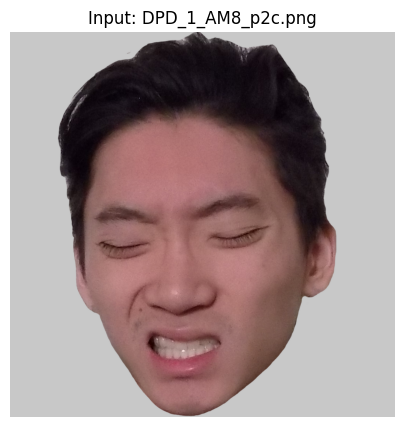


🔄 Ensemble predictions từ 10 folds:
------------------------------------------------------------
  ✓ Fold 1 : Score = 3.0262
  ✓ Fold 10: Score = 4.2982
  ✓ Fold 2 : Score = 3.7456
  ✓ Fold 3 : Score = 3.5902
  ✓ Fold 4 : Score = 3.4010
  ✓ Fold 5 : Score = 3.3009
  ✓ Fold 6 : Score = 3.9436
  ✓ Fold 7 : Score = 3.3902
  ✓ Fold 8 : Score = 4.0408
  ✓ Fold 9 : Score = 3.6890
------------------------------------------------------------
📊 ENSEMBLE RESULT:
   • Mean Score: 3.6426
   • Std Dev:    0.3624
   • Min/Max:    3.0262 / 4.2982
   • Folds used: 10
------------------------------------------------------------

🎯 MỨC ĐỘ ĐAU (ENSEMBLE 10-FOLD): 3.6426 ± 0.3624 / 7.0
🔍 Nhận định: Đau nhiều / Dữ dội


In [3]:
# -*- coding: utf-8 -*-
"""
Script kiểm tra Model V11 (Fairness Version) - ENSEMBLE 10 FOLDS
Sử dụng trung bình của 10 checkpoints để dự đoán (Gold standard for inference)
"""
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image, ImageOps
import timm
import os
import matplotlib.pyplot as plt
import glob

# cấu hình xử lý màu ảnh theo Median Face Luminance
import cv2
import numpy as np
from PIL import Image
class SmartMedianFaceLuminance:
    def __init__(self, target_median=128, center_crop_ratio=0.7):
        """
        - target_median: Điểm trung vị độ sáng bạn muốn (thường để 128 là dải xám chuẩn).
        - center_crop_ratio: (0.7) nghĩa là thuật toán sẽ chỉ khoanh lấy 70% 
          vùng trung tâm mặt để đo độ sáng, nhằm bỏ qua phần quần áo/phông nền.
        """
        self.target_median = target_median
        self.center_crop_ratio = center_crop_ratio
        
    def __call__(self, img):
        if not isinstance(img, Image.Image):
            return img
            
        # 1. Chuyển sang mảng Numpy và tách dải màu LAB (L là Luminance - Độ sáng)
        img_np = np.array(img.convert("RGB"))
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        
        # 2. Tính tọa độ vùng trích xuất trung tâm khuôn mặt
        h, w = l.shape
        crop_h, crop_w = int(h * self.center_crop_ratio), int(w * self.center_crop_ratio)
        start_y, start_x = (h - crop_h) // 2, (w - crop_w) // 2
        
        l_center = l[start_y:start_y+crop_h, start_x:start_x+crop_w]
        
        # 3. Lấy độ sáng trung vị (Median Luminance) của RIÊNG VÙNG MẶT KHÁCH
        current_median = np.median(l_center)
        
        # 4. Tính toán độ chênh lệch và bù sáng cho TOÀN BỘ ẢNH
        if current_median > 0:
            # Dùng phép tính dịch chuyển ánh sáng (Shift) mềm mại hơn phép nhân
            shift = int(self.target_median - current_median)
            
            # Ép kiểu an toàn bằng cv2 tránh vượt ngưỡng gây nhiễu màu
            if shift > 0:
                l_adjusted = cv2.add(l, shift)
            else:
                l_adjusted = cv2.subtract(l, abs(shift))
            
            # Ráp lại 3 kênh màu L-A-B
            lab_adjusted = cv2.merge((l_adjusted, a, b))
            
            # Chuyển ngược về không gian RGB gởi đi
            img_normalized = cv2.cvtColor(lab_adjusted, cv2.COLOR_LAB2RGB)
            return Image.fromarray(img_normalized)
            
        return img

# === 1. CẤU HÌNH ===
class Config:
    BACKBONE = 'efficientnet_b3' 
    IMG_SIZE = 300                
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Tự động lấy V11 checkpoints (thay hoặc để trống để tự động tìm)
    V11_CHECKPOINT_PATTERN = "checkpoints/2026-03-31_11-45-57_RGB_MedianFaceLuminance_V11_Fairness_fold_*.pth"
    
    # Ảnh cần test
    TEST_IMAGE_PATH = "dataset_osfstorage-archive/Stimuli/Expression Images/Corlor Skin/white/DPD_1_AM8_p2c.png"
    
    # TEST_IMAGE_PATH = "ANH DA CHINH/{1A533651-4451-413A-A7F9-301411BC485E}.png"
    
    
    # TEST_IMAGE_PATH = "ANH DA CHINH/{1A533651-4451-413A-A7F9-301411BC485E}.png"
    # TEST_IMAGE_PATH = "ANH DA CHINH/{7E91882F-AEFE-4ECC-B0C2-4B58FDF160FB}.png"
    
    # TEST_IMAGE_PATH = "ANH DA CHINH/{A4C66CEF-2EC7-442F-BFE6-68139C45CBF8}.png"
    
    # TEST_IMAGE_PATH = "ANH DA CHINH/pexels-olly-3812761.png"

cfg = Config()

# === 2. KIẾN TRÚC MODEL ===
class BaselinePainModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.backbone = timm.create_model(cfg.BACKBONE, pretrained=False, num_classes=0, global_pool='avg')
        # V11: Dropout(0.3) - khác V10 là 0.4
        self.pain_head = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(self.backbone.num_features, 1)
        )

    def forward(self, x):
        return self.pain_head(self.backbone(x))

# === 3. HÀM DỰ ĐOÁN (ENSEMBLE) ===
def predict_pain_level_ensemble(image_path, checkpoint_paths, config):
    """
    Dự đoán mức độ đau sử dụng ENSEMBLE của 10 folds
    (Trung bình cộng predictions từ 10 models)
    """
    val_transform = transforms.Compose([
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        SmartMedianFaceLuminance(target_median=128, center_crop_ratio=0.7), # Bù sáng
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    try:
        if not os.path.exists(image_path):
            print(f"LỖI: Không tìm thấy ảnh tại {image_path}")
            return None, None

        # Xử lý ảnh
        # img_pil = Image.open(image_path)
        # img_pil = ImageOps.exif_transpose(img_pil) # Fix xoay
        # img_pil = img_pil.convert("RGB")
        
        # Xử lý ảnh (Tự động bù nền cho ảnh bị xóa phông)
        img_pil = Image.open(image_path)
        img_pil = ImageOps.exif_transpose(img_pil) # Fix xoay
        
        # Nếu ảnh có kênh Alpha (trong suốt)
        if img_pil.mode in ('RGBA', 'LA') or (img_pil.mode == 'P' and 'transparency' in img_pil.info):
            # Tạo một cái nền màu xám nhạt (RGB: 200, 200, 200) thay vì đen sì
            background = Image.new("RGB", img_pil.size, (200, 200, 200)) 
            background.paste(img_pil, mask=img_pil.convert('RGBA').split()[3]) # Dán mặt lên
            img_pil = background
        else:
            img_pil = img_pil.convert("RGB")


        # Hiển thị ảnh
        plt.figure(figsize=(5, 5))
        plt.imshow(img_pil)
        plt.axis('off')
        plt.title(f"Input: {os.path.basename(image_path)}")
        plt.show(block=False)
        plt.pause(1) 
        plt.close()

        # Chuẩn bị tensor
        img_tensor = val_transform(img_pil).unsqueeze(0).to(config.DEVICE)
        
        # === ENSEMBLE: Chạy 10 models và lấy trung bình ===
        predictions = []
        print(f"\n🔄 Ensemble predictions từ {len(checkpoint_paths)} folds:")
        print("-" * 60)
        
        for i, checkpoint_path in enumerate(sorted(checkpoint_paths), 1):
            if not os.path.exists(checkpoint_path):
                print(f"  ⚠️  Fold {i}: File không tìm thấy - SKIP")
                continue
                
            fold_num = os.path.basename(checkpoint_path).split('fold_')[-1].replace('.pth', '')
            
            model = BaselinePainModel(config).to(config.DEVICE)
            model.load_state_dict(torch.load(checkpoint_path, map_location=config.DEVICE))
            model.eval()
            
            with torch.no_grad():
                pred = model(img_tensor).item()
                predictions.append(pred)
                print(f"  ✓ Fold {fold_num:2s}: Score = {pred:6.4f}")
        
        if not predictions:
            print("❌ Không có predictions nào!")
            return None, None
        
        # Tính ensemble score (trung bình)
        ensemble_score = sum(predictions) / len(predictions)
        std_score = (sum((p - ensemble_score)**2 for p in predictions) / len(predictions))**0.5
        
        print("-" * 60)
        print(f"📊 ENSEMBLE RESULT:")
        print(f"   • Mean Score: {ensemble_score:.4f}")
        print(f"   • Std Dev:    {std_score:.4f}")
        print(f"   • Min/Max:    {min(predictions):.4f} / {max(predictions):.4f}")
        print(f"   • Folds used: {len(predictions)}")
        print("-" * 60)
        
        return ensemble_score, std_score

    except Exception as e:
        print(f"Lỗi: {e}")
        return None, None

# === 4. CHẠY ===
if __name__ == "__main__":
    print("\n" + "="*60)
    print("🧪 TESTING MODEL V11 (Fairness) - ENSEMBLE 10-FOLD MODE")
    print("="*60)
    
    # Tìm checkpoints V11
    checkpoint_files = glob.glob(cfg.V11_CHECKPOINT_PATTERN)
    
    if not checkpoint_files:
        # Fallback: Tìm checkpoint mới nhất (V11)
        if os.path.exists("checkpoints"):
            all_files = [os.path.join("checkpoints", f) for f in os.listdir("checkpoints") 
                        if "V11" in f and f.endswith(".pth")]
            checkpoint_files = all_files
    
    if checkpoint_files:
        print(f"\n✓ Tìm thấy {len(checkpoint_files)} V11 checkpoints")
        for cp in sorted(checkpoint_files):
            print(f"  - {os.path.basename(cp)}")
    else:
        print("❌ Không tìm thấy checkpoint V11 nào!")
        print(f"   Pattern tìm: {cfg.V11_CHECKPOINT_PATTERN}")
        exit()
    
    # Load ensemble
    ensemble_score, std_score = predict_pain_level_ensemble(cfg.TEST_IMAGE_PATH, checkpoint_files, cfg)
    
    if ensemble_score is not None:
        print("\n" + "="*60)
        print(f"🎯 MỨC ĐỘ ĐAU (ENSEMBLE 10-FOLD): {ensemble_score:.4f} ± {std_score:.4f} / 7.0")
        print("="*60)
        
        # Phân loại
        if ensemble_score < 1.5: 
            diagnosis = "Không đau / Rất nhẹ"
        elif ensemble_score < 3.5: 
            diagnosis = "Đau nhẹ / Trung bình"
        else: 
            diagnosis = "Đau nhiều / Dữ dội"
        
        print(f"🔍 Nhận định: {diagnosis}")
        print("="*60)
    else:
        print("\n❌ Dự đoán thất bại!")


### So sánh Before - After (Smart Median Face Luminance)

Mục tiêu: chứng minh trực quan ảnh sáng rõ hơn sau khi áp dụng bù sáng theo median vùng trung tâm 70% khuôn mặt.


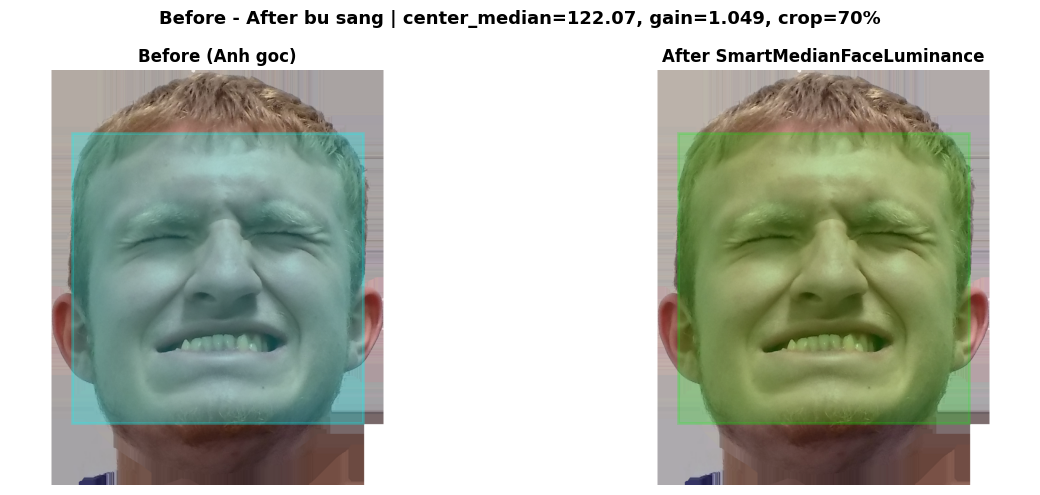

Da luu hinh so sanh tai: outputs\smart_median_face_luminance_before_after.png
Anh su dung: dataset_osfstorage-archive/Stimuli/Expression Images/Corlor Skin/white/DPD_1_WM34_p5c.png


In [1]:
import os
import glob
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


class SmartMedianFaceLuminance:
    def __init__(self, target_median=128, center_crop_ratio=0.7, min_gain=0.6, max_gain=2.2):
        self.target_median = float(target_median)
        self.center_crop_ratio = float(center_crop_ratio)
        self.min_gain = float(min_gain)
        self.max_gain = float(max_gain)

    def __call__(self, img_pil):
        img_rgb = ImageOps.exif_transpose(img_pil).convert("RGB")
        arr = np.asarray(img_rgb).astype(np.float32)

        # Luma theo Rec.601 để phản ánh độ sáng cảm nhận
        gray = 0.299 * arr[..., 0] + 0.587 * arr[..., 1] + 0.114 * arr[..., 2]

        h, w = gray.shape
        crop_h = max(1, int(h * self.center_crop_ratio))
        crop_w = max(1, int(w * self.center_crop_ratio))
        y0 = (h - crop_h) // 2
        x0 = (w - crop_w) // 2
        y1 = y0 + crop_h
        x1 = x0 + crop_w

        center_region = gray[y0:y1, x0:x1]
        center_median = float(np.median(center_region))

        eps = 1e-6
        gain = np.clip(self.target_median / (center_median + eps), self.min_gain, self.max_gain)

        corrected = np.clip(arr * gain, 0, 255).astype(np.uint8)
        corrected_img = Image.fromarray(corrected, mode="RGB")

        info = {
            "center_median": center_median,
            "gain": float(gain),
            "rect": (x0, y0, crop_w, crop_h),
        }
        return corrected_img, info


def pick_demo_image():
    candidates = [
        "ANH DA CHINH/{1A533651-4451-413A-A7F9-301411BC485E}.png",
        "ANH DA CHINH/{7E91882F-AEFE-4ECC-B0C2-4B58FDF160FB}.png",
        "ANH DA CHINH/{A4C66CEF-2EC7-442F-BFE6-68139C45CBF8}.png",
        "dataset_osfstorage-archive/Stimuli/Expression Images/Corlor Skin/white/DPD_1_WM34_p5c.png",
    ]
    for p in candidates:
        if os.path.exists(p):
            return p

    fallback = sorted(glob.glob("ANH DA CHINH/*.png") + glob.glob("ANH DA CHINH/*.jpg") + glob.glob("ANH DA CHINH/*.jpeg"))
    if fallback:
        return fallback[0]

    return None


img_path = pick_demo_image()
if img_path is None:
    raise FileNotFoundError("Khong tim thay anh demo. Hay dat anh trong thu muc 'ANH DA CHINH' hoac cap nhat duong dan.")

before_img = Image.open(img_path)
transform = SmartMedianFaceLuminance(target_median=128, center_crop_ratio=0.7)
after_img, meta = transform(before_img)

before_np = np.asarray(ImageOps.exif_transpose(before_img).convert("RGB"))
after_np = np.asarray(after_img)
x0, y0, rw, rh = meta["rect"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].imshow(before_np)
axes[0].add_patch(Rectangle((x0, y0), rw, rh, linewidth=2, edgecolor="cyan", facecolor="cyan", alpha=0.25))
axes[0].set_title("Before (Anh goc)", fontsize=12, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(after_np)
axes[1].add_patch(Rectangle((x0, y0), rw, rh, linewidth=2, edgecolor="lime", facecolor="lime", alpha=0.20))
axes[1].set_title("After SmartMedianFaceLuminance", fontsize=12, fontweight="bold")
axes[1].axis("off")

fig.suptitle(
    f"Before - After bu sang | center_median={meta['center_median']:.2f}, gain={meta['gain']:.3f}, crop=70%",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

os.makedirs("outputs", exist_ok=True)
out_path = os.path.join("outputs", "smart_median_face_luminance_before_after.png")
fig.savefig(out_path, dpi=200, bbox_inches="tight")
print(f"Da luu hinh so sanh tai: {out_path}")
print(f"Anh su dung: {img_path}")

## Script test model v11 với ENSEMBLE 10 FOLDS từ file test_list.txt

Script này test model V11 sử dụng ensemble của 10 folds mới nhất, đọc danh sách ảnh từ file test_list.txt trong exported_data, và tính toán metrics. Ảnh nằm trong các folder con của "Expression Images/Cropped and Standardized".


In [1]:
# -*- coding: utf-8 -*-
"""
Script kiểm tra Model V11 - Test từ file test_list.txt với ENSEMBLE 10 FOLDS
"""
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image, ImageOps
import timm
import os
import glob
from sklearn.metrics import mean_squared_error, mean_absolute_error

# cấu hình xử lý màu ảnh theo Median Face Luminance
import cv2
import numpy as np
from PIL import Image
class SmartMedianFaceLuminance:
    def __init__(self, target_median=128, center_crop_ratio=0.7):
        """
        - target_median: Điểm trung vị độ sáng bạn muốn (thường để 128 là dải xám chuẩn).
        - center_crop_ratio: (0.7) nghĩa là thuật toán sẽ chỉ khoanh lấy 70% 
          vùng trung tâm mặt để đo độ sáng, nhằm bỏ qua phần quần áo/phông nền.
        """
        self.target_median = target_median
        self.center_crop_ratio = center_crop_ratio
        
    def __call__(self, img):
        if not isinstance(img, Image.Image):
            return img
            
        # 1. Chuyển sang mảng Numpy và tách dải màu LAB (L là Luminance - Độ sáng)
        img_np = np.array(img.convert("RGB"))
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        
        # 2. Tính tọa độ vùng trích xuất trung tâm khuôn mặt
        h, w = l.shape
        crop_h, crop_w = int(h * self.center_crop_ratio), int(w * self.center_crop_ratio)
        start_y, start_x = (h - crop_h) // 2, (w - crop_w) // 2
        
        l_center = l[start_y:start_y+crop_h, start_x:start_x+crop_w]
        
        # 3. Lấy độ sáng trung vị (Median Luminance) của RIÊNG VÙNG MẶT KHÁCH
        current_median = np.median(l_center)
        
        # 4. Tính toán độ chênh lệch và bù sáng cho TOÀN BỘ ẢNH
        if current_median > 0:
            # Dùng phép tính dịch chuyển ánh sáng (Shift) mềm mại hơn phép nhân
            shift = int(self.target_median - current_median)
            
            # Ép kiểu an toàn bằng cv2 tránh vượt ngưỡng gây nhiễu màu
            if shift > 0:
                l_adjusted = cv2.add(l, shift)
            else:
                l_adjusted = cv2.subtract(l, abs(shift))
            
            # Ráp lại 3 kênh màu L-A-B
            lab_adjusted = cv2.merge((l_adjusted, a, b))
            
            # Chuyển ngược về không gian RGB gởi đi
            img_normalized = cv2.cvtColor(lab_adjusted, cv2.COLOR_LAB2RGB)
            return Image.fromarray(img_normalized)
            
        return img

# === 1. CẤU HÌNH ===
class Config:
    BACKBONE = 'efficientnet_b3' 
    IMG_SIZE = 300                
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Ensemble 10 folds
    V11_CHECKPOINT_PATTERN = "checkpoints/2026-03-31_11-45-57_RGB_MedianFaceLuminance_V11_Fairness_fold_*.pth"
    
    # File test_list.txt (dùng fold_1, giả sử giống nhau)
    TEST_LIST_PATH = "exported_data/2026-03-30_12-55-46_RGB_MedianFaceLuminance_V11_Fairness/fold_1/test_list.txt"
    
    # Base path cho ảnh - SỬ DỤNG FOLDER COLOR SKIN
    IMAGE_BASE_PATH = r"D:\DATA\Code\DelawarePain\dataset_osfstorage-archive\Stimuli\Expression Images\Corlor Skin"

cfg = Config()

# === 2. KIẾN TRÚC MODEL ===
class BaselinePainModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.backbone = timm.create_model(cfg.BACKBONE, pretrained=False, num_classes=0, global_pool='avg')
        # V11: Dropout(0.3)
        self.pain_head = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(self.backbone.num_features, 1)
        )

    def forward(self, x):
        return self.pain_head(self.backbone(x))

# === 3. HÀM DỰ ĐOÁN ENSEMBLE ===
def predict_pain_level_ensemble(image_path, checkpoint_paths, config):
    """Dự đoán ensemble từ 10 folds"""
    val_transform = transforms.Compose([
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        SmartMedianFaceLuminance(target_median=128, center_crop_ratio=0.7), # Bù sáng
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    try:
        if not os.path.exists(image_path):
            print(f"⚠️  Không tìm thấy ảnh: {image_path}")
            return None

        # Xử lý ảnh
        img_pil = Image.open(image_path)
        img_pil = ImageOps.exif_transpose(img_pil)
        
        if img_pil.mode in ('RGBA', 'LA') or (img_pil.mode == 'P' and 'transparency' in img_pil.info):
            background = Image.new("RGB", img_pil.size, (200, 200, 200))
            background.paste(img_pil, mask=img_pil.convert('RGBA').split()[3])
            img_pil = background
        else:
            img_pil = img_pil.convert("RGB")

        img_tensor = val_transform(img_pil).unsqueeze(0).to(config.DEVICE)
        
        # Ensemble
        predictions = []
        for checkpoint_path in sorted(checkpoint_paths):
            if not os.path.exists(checkpoint_path):
                continue
                
            model = BaselinePainModel(config).to(config.DEVICE)
            model.load_state_dict(torch.load(checkpoint_path, map_location=config.DEVICE))
            model.eval()
            
            with torch.no_grad():
                pred = model(img_tensor).item()
                predictions.append(pred)
        
        if not predictions:
            return None
        
        ensemble_score = sum(predictions) / len(predictions)
        return ensemble_score

    except Exception as e:
        return None

# === 4. HÀM MAP GROUP ĐẾN FOLDER ===
def get_image_path(image_name):
    """Tìm ảnh trong 3 folder: black, white, yellow dựa trên tên file"""
    
    # Mapping từ prefix trong tên file sang folder
    # BF = Black Female, BM = Black Male -> black
    # WF = White Female, WM = White Male -> white  
    # AF = Asian Female, AM = Asian Male, LF = Latinx Female, LM = Latinx Male, OF = Other Female, OM = Other Male -> yellow
    
    if image_name.startswith('DPD_1_BF') or image_name.startswith('DPD_1_BM'):
        folder = 'black'
    elif image_name.startswith('DPD_1_WF') or image_name.startswith('DPD_1_WM'):
        folder = 'white'
    else:
        # AF, AM, LF, LM, OF, OM hoặc các trường hợp khác -> yellow
        folder = 'yellow'
    
    candidate_path = os.path.join(cfg.IMAGE_BASE_PATH, folder, image_name)
    
    if os.path.exists(candidate_path):
        return candidate_path
    
    # Fallback: tìm trong tất cả 3 folder
    for color_folder in ['black', 'white', 'yellow']:
        search_path = os.path.join(cfg.IMAGE_BASE_PATH, color_folder, image_name)
        if os.path.exists(search_path):
            return search_path
    
    return candidate_path  # Trả về path mặc dù không tồn tại

# === 5. MAIN ===
if __name__ == '__main__':
    print("🚀 Bắt đầu test model V11 với ENSEMBLE 10 FOLDS từ test_list.txt")
    print(f"📋 Test list: {cfg.TEST_LIST_PATH}")
    print("-" * 60)
    
    # Tìm tất cả checkpoints
    checkpoint_paths = glob.glob(cfg.V11_CHECKPOINT_PATTERN)
    if not checkpoint_paths:
        print(f"❌ Không tìm thấy checkpoints: {cfg.V11_CHECKPOINT_PATTERN}")
        exit()
    
    print(f"✅ Tìm thấy {len(checkpoint_paths)} checkpoints")
    
    # Đọc test_list.txt
    if not os.path.exists(cfg.TEST_LIST_PATH):
        print(f"❌ Không tìm thấy test_list.txt: {cfg.TEST_LIST_PATH}")
        exit()
    
    with open(cfg.TEST_LIST_PATH, 'r') as f:
        lines = f.readlines()
    
    print(f"📊 Số ảnh test: {len(lines)}")
    print("-" * 60)
    
    # Test từng ảnh
    results = []  # List để lưu kết quả: (image_name, true_pain, pred_pain, error)
    
    for line in lines:
        parts = line.strip().split(' | ')
        if len(parts) >= 2:  # Ít nhất image_name và true_pain
            image_name = parts[0]
            true_pain_str = parts[1]
            true_pain = float(true_pain_str)
        else:
            continue
        
        # Tìm đường dẫn ảnh từ tên ảnh
        image_path = get_image_path(image_name)
        
        # Dự đoán ensemble
        pred_pain = predict_pain_level_ensemble(image_path, checkpoint_paths, cfg)
        
        if pred_pain is not None:
            error = abs(pred_pain - true_pain)
            results.append((image_name, true_pain, pred_pain, error))
        else:
            print(f"❌ {image_name} | Dự đoán thất bại")
    
    # Sort results theo error giảm dần
    results.sort(key=lambda x: x[3], reverse=True)
    
    # In kết quả đã sort
    print("\n📋 KẾT QUẢ TEST (SORT THEO ERROR GIẢM DẦN):")
    print("-" * 80)
    for image_name, true_pain, pred_pain, error in results:
        print(f"🖼️  {image_name:<50} | True: {true_pain:.4f} | Pred: {pred_pain:.4f} | Error: {error:.4f}")
    
    # Tính metrics
    if results:
        true_labels = [r[1] for r in results]
        pred_labels = [r[2] for r in results]
        mse = mean_squared_error(true_labels, pred_labels)
        mae = mean_absolute_error(true_labels, pred_labels)
        
        print("-" * 80)
        print("📈 METRICS:")
        print(f"   • MSE: {mse:.4f}")
        print(f"   • MAE: {mae:.4f}")
        print(f"   • Số ảnh thành công: {len(results)}/{len(lines)}")
    else:
        print("❌ Không có dự đoán nào thành công!")

d:\miniconda\envs\myENV\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 Bắt đầu test model V11 với ENSEMBLE 10 FOLDS từ test_list.txt
📋 Test list: exported_data/2026-03-30_12-55-46_RGB_MedianFaceLuminance_V11_Fairness/fold_1/test_list.txt
------------------------------------------------------------
✅ Tìm thấy 10 checkpoints
📊 Số ảnh test: 97
------------------------------------------------------------

📋 KẾT QUẢ TEST (SORT THEO ERROR GIẢM DẦN):
--------------------------------------------------------------------------------
🖼️  DPD_1_AM8_p2c.png                                  | True: 5.3000 | Pred: 3.6426 | Error: 1.6574
🖼️  DPD_1_WM10_p3.png                                  | True: 3.9268 | Pred: 2.3801 | Error: 1.5467
🖼️  DPD_1_BM8_p2c.png                                  | True: 3.9756 | Pred: 2.6175 | Error: 1.3581
🖼️  DPD_1_WM5_p1.png                                   | True: 5.4103 | Pred: 4.1647 | Error: 1.2456
🖼️  DPD_1_OM2_p2c.png                                  | True: 4.5490 | Pred: 3.3140 | Error: 1.2350
🖼️  DPD_1_LF11_p2c.png             

In [2]:
# # Phân tích MAE theo nhóm
# from collections import defaultdict

# group_errors = defaultdict(list)
# with open(cfg.TEST_LIST_PATH, 'r') as f:
#     lines = f.readlines()

# for line in lines:
#     parts = line.strip().split(' | ')
#     if len(parts) < 3: continue
#     image_name, true_pain, group = parts[0], float(parts[1]), parts[2]
    
#     image_path = get_image_path(image_name)
#     pred = predict_pain_level_ensemble(image_path, checkpoint_paths, cfg)
#     if pred:
#         group_errors[group].append(abs(pred - true_pain))

# print("\n📊 MAE THEO NHÓM:")
# for group, errors in sorted(group_errors.items()):
#     print(f"  {group:<20}: MAE = {sum(errors)/len(errors):.4f} ({len(errors)} ảnh)")

# Thêm vào cuối test script
from collections import defaultdict

group_errors = defaultdict(list)
for line in lines:
    parts = line.strip().split(' | ')
    if len(parts) < 3: continue
    name, true_pain, group = parts[0], float(parts[1]), parts[2]
    image_path = get_image_path(name)
    pred = predict_pain_level_ensemble(image_path, checkpoint_paths, cfg)
    if pred: group_errors[group].append(abs(pred - true_pain))

print("\n📊 FAIRNESS ANALYSIS:")
maes = {}
for group in sorted(group_errors):
    mae_g = sum(group_errors[group]) / len(group_errors[group])
    maes[group] = mae_g
    print(f"  {group:<20}: MAE = {mae_g:.4f} ({len(group_errors[group])} ảnh)")

gap = max(maes.values()) - min(maes.values())
print(f"\n  📏 Fairness Gap: {gap:.4f}")


📊 FAIRNESS ANALYSIS:
  Black_Female        : MAE = 0.3172 (14 ảnh)
  Black_Male          : MAE = 0.5960 (12 ảnh)
  White_Female        : MAE = 0.4978 (33 ảnh)
  White_Male          : MAE = 0.5031 (23 ảnh)
  Yellow_Female       : MAE = 0.4913 (10 ảnh)
  Yellow_Male         : MAE = 0.2552 (5 ảnh)

  📏 Fairness Gap: 0.3408


## stript test nhiều ảnh facegen 1 lúc model v11.0


In [4]:
# -*- coding: utf-8 -*-
"""
Script kiểm tra Model V11 (Fairness Version) - Test FaceGen Batch ENSEMBLE
Sử dụng trung bình của 10 checkpoints để dự đoán từng ảnh
"""
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image, ImageOps
import timm
import os
import glob
from pathlib import Path
import pandas as pd
import numpy as np

# === 1. CẤU HÌNH ===
class Config:
    BACKBONE = 'efficientnet_b3' 
    IMG_SIZE = 300                
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # V11 checkpoints pattern
    V11_CHECKPOINT_PATTERN = "checkpoints/*_V11_Fairness_fold_*.pth"
    
    # Folder FaceGen
    TEST_FOLDER = "dataset_osfstorage-archive/Stimuli/FaceGen/Modeller"

cfg = Config()

# === 2. KIẾN TRÚC MODEL ===
class BaselinePainModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.backbone = timm.create_model(cfg.BACKBONE, pretrained=False, num_classes=0, global_pool='avg')
        self.pain_head = nn.Sequential(
            nn.Dropout(p=0.3),  # V11: 0.3 (not 0.4)
            nn.Linear(self.backbone.num_features, 1)
        )

    def forward(self, x):
        return self.pain_head(self.backbone(x))

# === 3. HÀM DỰ ĐOÁN (ENSEMBLE) ===
def predict_pain_level_ensemble(image_path, models, config):
    """
    Dự đoán mức độ đau sử dụng ENSEMBLE của 10 folds
    """
    val_transform = transforms.Compose([
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    try:
        if not os.path.exists(image_path):
            return None, None

        # Xử lý ảnh
        img_pil = Image.open(image_path)
        img_pil = ImageOps.exif_transpose(img_pil) 
        img_pil = img_pil.convert("RGB")
        
        # Chuẩn bị tensor
        img_tensor = val_transform(img_pil).unsqueeze(0).to(config.DEVICE)
        
        # === ENSEMBLE: Chạy 10 models và lấy trung bình ===
        predictions = []
        for model in models:
            with torch.no_grad():
                pred = model(img_tensor).item()
                predictions.append(pred)
        
        if not predictions:
            return None, None
        
        # Tính ensemble score (trung bình)
        ensemble_score = sum(predictions) / len(predictions)
        std_score = (sum((p - ensemble_score)**2 for p in predictions) / len(predictions))**0.5
        
        return ensemble_score, std_score

    except Exception as e:
        return None, None


def get_all_images(folder_path, extensions=('.jpg', '.jpeg', '.png')):
    """
    Lấy tất cả ảnh trong folder và các subfolder
    """
    image_files = []
    for ext in extensions:
        pattern = os.path.join(folder_path, f'**/*{ext}')
        image_files.extend(glob.glob(pattern, recursive=True))
        pattern = os.path.join(folder_path, f'**/*{ext.upper()}')
        image_files.extend(glob.glob(pattern, recursive=True))
    
    return sorted(list(set(image_files)))


def categorize_pain_level(score):
    """Phân loại mức độ đau dựa trên score"""
    if score < 1.5:
        return "Không đau/Rất nhẹ"
    elif score < 3.5:
        return "Đau nhẹ/Trung bình"
    else:
        return "Đau nhiều/Dữ dội"


def load_all_models(checkpoint_paths, config):
    """Load tất cả 10 models vào memory"""
    models = []
    for checkpoint_path in sorted(checkpoint_paths):
        if not os.path.exists(checkpoint_path):
            continue
        model = BaselinePainModel(config).to(config.DEVICE)
        model.load_state_dict(torch.load(checkpoint_path, map_location=config.DEVICE))
        model.eval()
        models.append(model)
    return models


def test_batch_ensemble(models, config, show_images=False, max_images=None):
    """
    Test batch hình ảnh từ FaceGen sử dụng ENSEMBLE
    """
    
    # Lấy danh sách ảnh
    print(f"\n🔍 Quét ảnh trong: {config.TEST_FOLDER}")
    image_files = get_all_images(config.TEST_FOLDER)
    
    if not image_files:
        print("❌ Không tìm thấy ảnh nào!")
        return
    
    if max_images:
        image_files = image_files[:max_images]
    
    print(f"✓ Tìm thấy {len(image_files)} ảnh\n")
    
    # Test từng ảnh
    results = []
    for idx, image_path in enumerate(image_files, 1):
        filename = os.path.basename(image_path)
        folder_name = os.path.basename(os.path.dirname(image_path))
        
        print(f"[{idx:3d}/{len(image_files)}] {folder_name:40s} | {filename:40s} | ", end="", flush=True)
        
        score, std = predict_pain_level_ensemble(image_path, models, config)
        
        if score is not None:
            diagnosis = categorize_pain_level(score)
            print(f"Score: {score:6.4f}±{std:5.4f} ({diagnosis})")
            results.append({
                'folder': folder_name,
                'filename': filename,
                'full_path': image_path,
                'score': score,
                'std': std,
                'diagnosis': diagnosis
            })
        else:
            print("SKIP - Lỗi")
    
    # === THỐNG KÊ ===
    if results:
        print("\n" + "="*130)
        print("📊 THỐNG KÊ KẾT QUẢ - TEST FACEGEN MODELLER (ENSEMBLE 10-FOLD)")
        print("="*130)
        
        scores = [r['score'] for r in results]
        stds = [r['std'] for r in results]
        
        print(f"\n📈 Thống kê toàn bộ FaceGen (Modeller - Ensemble):")
        print(f"   • Tổng ảnh: {len(results)}")
        print(f"   • Score min: {min(scores):.4f}")
        print(f"   • Score max: {max(scores):.4f}")
        print(f"   • Score trung bình: {sum(scores)/len(scores):.4f}")
        print(f"   • Score độ lệch chuẩn: {(sum((x - sum(scores)/len(scores))**2 for x in scores) / len(scores))**0.5:.4f}")
        print(f"   • Avg Std (10-fold variance): {sum(stds)/len(stds):.4f}")
        
        # Thống kê theo folder
        print(f"\n📁 Thống kê theo folder trong Modeller:")
        folder_stats = {}
        for r in results:
            folder_key = r['folder']
            if folder_key not in folder_stats:
                folder_stats[folder_key] = []
            folder_stats[folder_key].append(r['score'])
        
        for folder_key in sorted(folder_stats.keys()):
            folder_scores = folder_stats[folder_key]
            print(f"   • {folder_key:50s}: {len(folder_scores):3d} ảnh | " +
                  f"Mean={sum(folder_scores)/len(folder_scores):.4f} | " +
                  f"Min={min(folder_scores):.4f} | Max={max(folder_scores):.4f}")
        
        # Top 5 ảnh đau nhất
        print(f"\n🔴 Top 5 ảnh FaceGen Modeller có score cao nhất (đau nhất):")
        for i, r in enumerate(sorted(results, key=lambda x: x['score'], reverse=True)[:5], 1):
            print(f"   {i}. {r['folder']:30s} | {r['filename']:40s} | Score: {r['score']:.4f}±{r['std']:.4f}")
        
        # Top 5 ảnh đau ít nhất
        print(f"\n🟢 Top 5 ảnh FaceGen Modeller có score thấp nhất (đau ít):")
        for i, r in enumerate(sorted(results, key=lambda x: x['score'])[:5], 1):
            print(f"   {i}. {r['folder']:30s} | {r['filename']:40s} | Score: {r['score']:.4f}±{r['std']:.4f}")
        
        # === XUẤT KẾT QUẢ RA CSV ===
        df_results = pd.DataFrame(results)
        csv_filename = "facegen_test_results_v11_ensemble.csv"
        df_results.to_csv(csv_filename, index=False, encoding='utf-8-sig')
        print(f"\n💾 Kết quả đã lưu vào: {csv_filename}")
        
        print("\n" + "="*130)
    
    return results


# === 4. CHẠY CHƯƠNG TRÌNH ===
if __name__ == "__main__":
    print("\n" + "="*130)
    print("🧪 TESTING MODEL V11 (Fairness Version) - FaceGen Modeller ENSEMBLE 10-FOLD Mode")
    print("="*130)
    
    # Tìm checkpoints V11
    checkpoint_files = glob.glob(cfg.V11_CHECKPOINT_PATTERN)
    
    if not checkpoint_files:
        # Fallback: Tìm checkpoint mới nhất (V11)
        if os.path.exists("checkpoints"):
            all_files = [os.path.join("checkpoints", f) for f in os.listdir("checkpoints") 
                        if "V11" in f and f.endswith(".pth")]
            checkpoint_files = all_files
    
    if checkpoint_files:
        print(f"\n✓ Tìm thấy {len(checkpoint_files)} V11 checkpoints")
        for cp in sorted(checkpoint_files)[:10]:  # Hiển thị max 10
            print(f"  - {os.path.basename(cp)}")
    else:
        print("❌ Không tìm thấy checkpoint V11 nào!")
        print(f"   Pattern tìm: {cfg.V11_CHECKPOINT_PATTERN}")
        exit()
    
    # Load tất cả models
    print(f"\n⚙️ Thiết bị: {cfg.DEVICE}")
    print(f"📦 Loading {len(checkpoint_files)} models...")
    models = load_all_models(checkpoint_files, cfg)
    print(f"✓ Đã load {len(models)} models")
    
    # Test batch FaceGen
    print(f"✓ Folder test: {cfg.TEST_FOLDER}")
    results = test_batch_ensemble(models, cfg, show_images=False, max_images=None)



🧪 TESTING MODEL V11 (Fairness Version) - FaceGen Modeller ENSEMBLE 10-FOLD Mode

✓ Tìm thấy 10 V11 checkpoints
  - 2026-02-20_19-11-26_V11_Fairness_fold_1.pth
  - 2026-02-20_19-11-26_V11_Fairness_fold_10.pth
  - 2026-02-20_19-11-26_V11_Fairness_fold_2.pth
  - 2026-02-20_19-11-26_V11_Fairness_fold_3.pth
  - 2026-02-20_19-11-26_V11_Fairness_fold_4.pth
  - 2026-02-20_19-11-26_V11_Fairness_fold_5.pth
  - 2026-02-20_19-11-26_V11_Fairness_fold_6.pth
  - 2026-02-20_19-11-26_V11_Fairness_fold_7.pth
  - 2026-02-20_19-11-26_V11_Fairness_fold_8.pth
  - 2026-02-20_19-11-26_V11_Fairness_fold_9.pth

⚙️ Thiết bị: cuda
📦 Loading 10 models...
✓ Đã load 10 models
✓ Folder test: dataset_osfstorage-archive/Stimuli/FaceGen/Modeller

🔍 Quét ảnh trong: dataset_osfstorage-archive/Stimuli/FaceGen/Modeller
✓ Tìm thấy 144 ảnh

[  1/144] AF1                                      | AF1.jpg                                  | Score: 2.0224±0.2432 (Đau nhẹ/Trung bình)
[  2/144] AF1                                    

## stript grandcam model v11.0



🔍 GRAD-CAM ANALYSIS - V11 ENSEMBLE (10-FOLD)
🖼️  Ảnh test: DPD_1_WM34_p5c.png
📐 IMG_SIZE: 300
📦 Checkpoint: checkpoints/2026-03-20_12-02-16_V11_Fairness_fold_*.pth

🔄 Ensemble GradCAM++ từ 10 models...


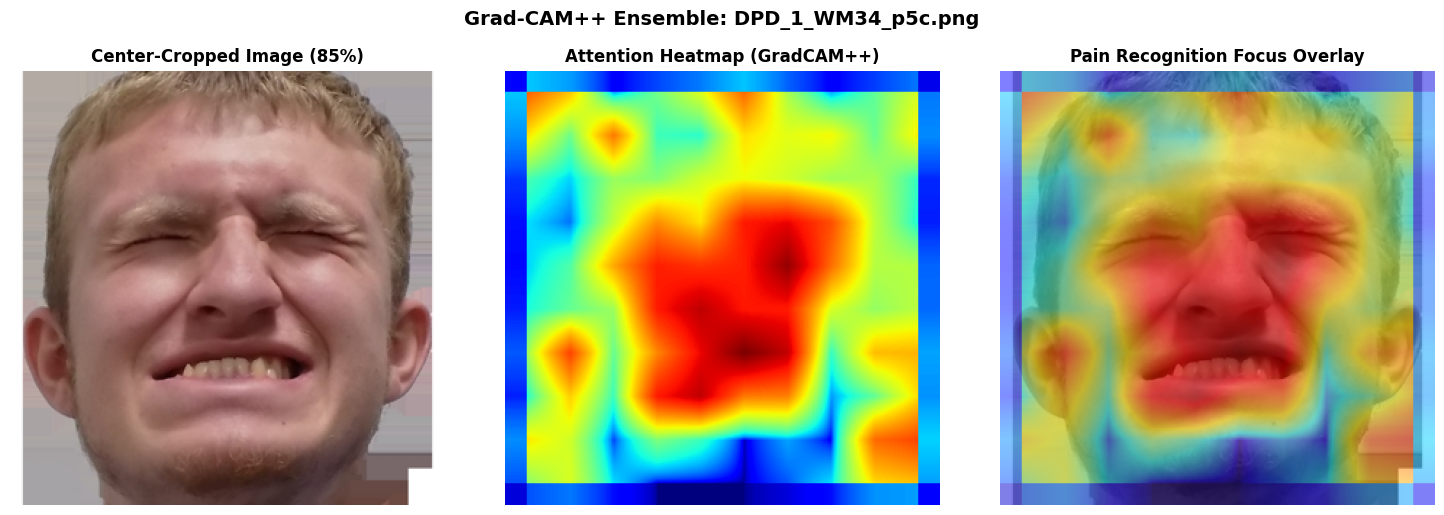


📖 HƯỚNG DẪN ĐỌC HEATMAP (GRAD-CAM++)
🔴 ĐỎ/VÀNG: Vùng model tập trung cao nhất
🔵 XANH DƯƠNG: Vùng model không quan tâm
✅ Tốt: Tập trung vào mắt (AU6/AU7), mũi, miệng



In [6]:
# -*- coding: utf-8 -*-
"""
ENSEMBLE GRADCAM for V11 (10-Fold Ensemble)
Visualizes which facial regions the model uses to predict pain
"""
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image, ImageOps
import timm
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image

# === CONFIG ===
class Config:
    BACKBONE = 'efficientnet_b3'
    IMG_SIZE = 300  # ← Phải khớp với lúc train
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    V11_CHECKPOINT_PATTERN = "checkpoints/2026-03-20_12-02-16_V11_Fairness_fold_*.pth"

    # Thay đường dẫn ảnh tại đây:
    IMG_PATH = "dataset_osfstorage-archive/Stimuli/Expression Images/Corlor Skin/white/DPD_1_WM34_p5c.png"
    # IMG_PATH = "dataset_osfstorage-archive/Stimuli/Expression Images/Cropped and Standardized/Black male participants/DPD_1_BM1alt_p5.png"

cfg = Config()

# === MODEL ARCHITECTURE ===
class BaselinePainModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.backbone = timm.create_model(cfg.BACKBONE, pretrained=False, num_classes=0, global_pool='avg')
        self.pain_head = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(self.backbone.num_features, 1)
        )
    def forward(self, x):
        return self.pain_head(self.backbone(x))

# === SMART CENTER CROP ===
def smart_crop_face(image_pil, crop_percentage=85):
    w, h = image_pil.size
    crop_frac = crop_percentage / 100.0
    left = int(w * (1 - crop_frac) / 2)
    top = int(h * (1 - crop_frac) / 2)
    right = int(w * (1 + crop_frac) / 2)
    bottom = int(h * (1 + crop_frac) / 2)
    return image_pil.crop((left, top, right, bottom))

# === LOAD ENSEMBLE ===
def load_ensemble_models(checkpoint_pattern, config):
    checkpoint_files = glob.glob(checkpoint_pattern)
    if not checkpoint_files and os.path.exists("checkpoints"):
        checkpoint_files = [os.path.join("checkpoints", f) for f in os.listdir("checkpoints") if "V11" in f and f.endswith(".pth")]
    if not checkpoint_files:
        print("❌ Không tìm thấy checkpoint V11 nào!")
        return []
    models = []
    for checkpoint_path in sorted(checkpoint_files)[:10]:
        model = BaselinePainModel(config).to(config.DEVICE)
        model.load_state_dict(torch.load(checkpoint_path, map_location=config.DEVICE))
        model.eval()
        models.append(model)
    return models

# === ENSEMBLE GRADCAM ===
def ensemble_gradcam(image_path, models, config):
    img_pil = Image.open(image_path)
    img_pil = ImageOps.exif_transpose(img_pil).convert("RGB")
    img_pil_cropped = smart_crop_face(img_pil, crop_percentage=85)
    img_pil_resized = img_pil_cropped.resize((config.IMG_SIZE, config.IMG_SIZE))
    rgb_img = np.float32(img_pil_resized) / 255

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
    input_tensor = transform(img_pil_resized).unsqueeze(0).to(config.DEVICE)

    all_cams = []
    print(f"\n🔄 Ensemble GradCAM++ từ {len(models)} models...")
    for model in models:
        try:
            target_layers = [model.backbone.blocks[-2][-1]]
            cam = GradCAMPlusPlus(model=model, target_layers=target_layers)
            grayscale_cam = cam(input_tensor=input_tensor, targets=None)
            all_cams.append(grayscale_cam[0, :])
        except:
            pass

    if not all_cams:
        return None, None, None

    ensemble_cam = np.mean(all_cams, axis=0)

    # Làm mờ viền ngoài (artifact từ zero-padding)
    h, w = ensemble_cam.shape
    ey, ex = int(h * 0.05), int(w * 0.05)
    ensemble_cam[:ey, :] *= 0.1
    ensemble_cam[-ey:, :] *= 0.1
    ensemble_cam[:, :ex] *= 0.1
    ensemble_cam[:, -ex:] *= 0.1

    ecc_min, ecc_max = ensemble_cam.min(), ensemble_cam.max()
    if ecc_max > ecc_min:
        ensemble_cam_normalized = (ensemble_cam - ecc_min) / (ecc_max - ecc_min)
    else:
        ensemble_cam_normalized = ensemble_cam

    ensemble_cam_enhanced = np.power(ensemble_cam_normalized, 0.4)
    return rgb_img, ensemble_cam_normalized, ensemble_cam_enhanced

# === VISUALIZE ===
def visualize_gradcam(rgb_img, cam_original, cam_enhanced, image_path):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(rgb_img)
    axes[0].axis('off')
    axes[0].set_title('Center-Cropped Image (85%)', fontsize=12, fontweight='bold')

    axes[1].imshow(plt.get_cmap('jet')(cam_enhanced))
    axes[1].axis('off')
    axes[1].set_title('Attention Heatmap (GradCAM++)', fontsize=12, fontweight='bold')

    overlay = show_cam_on_image(rgb_img, cam_enhanced, use_rgb=True)
    axes[2].imshow(overlay)
    axes[2].axis('off')
    axes[2].set_title('Pain Recognition Focus Overlay', fontsize=12, fontweight='bold')

    fig.suptitle(f"Grad-CAM++ Ensemble: {os.path.basename(image_path)}",
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# ================= RUN ====================
print("\n" + "="*60)
print("🔍 GRAD-CAM ANALYSIS - V11 ENSEMBLE (10-FOLD)")
print("="*60)
print(f"🖼️  Ảnh test: {os.path.basename(cfg.IMG_PATH)}")
print(f"📐 IMG_SIZE: {cfg.IMG_SIZE}")
print(f"📦 Checkpoint: {cfg.V11_CHECKPOINT_PATTERN}")

models = load_ensemble_models(cfg.V11_CHECKPOINT_PATTERN, cfg)
if models:
    rgb_img, cam_original, cam_enhanced = ensemble_gradcam(cfg.IMG_PATH, models, cfg)
    if rgb_img is not None:
        visualize_gradcam(rgb_img, cam_original, cam_enhanced, cfg.IMG_PATH)
        print("\n" + "="*60)
        print("📖 HƯỚNG DẪN ĐỌC HEATMAP (GRAD-CAM++)")
        print("="*60)
        print("🔴 ĐỎ/VÀNG: Vùng model tập trung cao nhất")
        print("🔵 XANH DƯƠNG: Vùng model không quan tâm")
        print("✅ Tốt: Tập trung vào mắt (AU6/AU7), mũi, miệng")
        print("="*60 + "\n")


## Script GRADCAM cho danh sách ảnh từ test_list.txt

Script này sẽ:

- Đọc `test_list.txt` (cùng file dùng để test ensemble)
- Lấy đường dẫn ảnh trong thư mục `Expression Images/Cropped and Standardized`
- Chạy **Ensemble GradCAM++ (10 folds)** và xuất ảnh overlay vào thư mục `outputs/gradcam_test_list`


In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# -*- coding: utf-8 -*-
"""GRADCAM BATCH - dùng test_list.txt (cùng danh sách đã dùng cho ensemble pre-check)"""
import pandas as pd
import os
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image, ImageOps
import timm
import glob
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image

# cấu hình xử lý màu ảnh theo Median Face Luminance
import cv2
import numpy as np
from PIL import Image
class SmartMedianFaceLuminance:
    def __init__(self, target_median=128, center_crop_ratio=0.7):
        """
        - target_median: Điểm trung vị độ sáng bạn muốn (thường để 128 là dải xám chuẩn).
        - center_crop_ratio: (0.7) nghĩa là thuật toán sẽ chỉ khoanh lấy 70% 
          vùng trung tâm mặt để đo độ sáng, nhằm bỏ qua phần quần áo/phông nền.
        """
        self.target_median = target_median
        self.center_crop_ratio = center_crop_ratio
        
    def __call__(self, img):
        if not isinstance(img, Image.Image):
            return img
            
        # 1. Chuyển sang mảng Numpy và tách dải màu LAB (L là Luminance - Độ sáng)
        img_np = np.array(img.convert("RGB"))
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        
        # 2. Tính tọa độ vùng trích xuất trung tâm khuôn mặt
        h, w = l.shape
        crop_h, crop_w = int(h * self.center_crop_ratio), int(w * self.center_crop_ratio)
        start_y, start_x = (h - crop_h) // 2, (w - crop_w) // 2
        
        l_center = l[start_y:start_y+crop_h, start_x:start_x+crop_w]
        
        # 3. Lấy độ sáng trung vị (Median Luminance) của RIÊNG VÙNG MẶT KHÁCH
        current_median = np.median(l_center)
        
        # 4. Tính toán độ chênh lệch và bù sáng cho TOÀN BỘ ẢNH
        if current_median > 0:
            # Dùng phép tính dịch chuyển ánh sáng (Shift) mềm mại hơn phép nhân
            shift = int(self.target_median - current_median)
            
            # Ép kiểu an toàn bằng cv2 tránh vượt ngưỡng gây nhiễu màu
            if shift > 0:
                l_adjusted = cv2.add(l, shift)
            else:
                l_adjusted = cv2.subtract(l, abs(shift))
            
            # Ráp lại 3 kênh màu L-A-B
            lab_adjusted = cv2.merge((l_adjusted, a, b))
            
            # Chuyển ngược về không gian RGB gởi đi
            img_normalized = cv2.cvtColor(lab_adjusted, cv2.COLOR_LAB2RGB)
            return Image.fromarray(img_normalized)
            
        return img

# === HÀM XUẤT BÁO CÁO HTML ===
def generate_html_report(true_labels, pred_labels, image_names, output_dir, html_filename="index_gradcam_report.html"):
    """Tạo file HTML hiển thị GradCAM từ lớn đến bé theo Error"""
    results = []
    for t_val, p_val, img_name in zip(true_labels, pred_labels, image_names):
        error = abs(t_val - p_val)
        cam_filename = os.path.splitext(img_name)[0] + "_gradcam.png"
        results.append({
            'image_name': img_name,
            'true_pain': t_val,
            'pred_pain': p_val,
            'error': error,
            'image_path': cam_filename
        })
        
    results.sort(key=lambda x: x['error'], reverse=True)
    
    html_content = """
    <!DOCTYPE html>
    <html lang="en">
    <head>
        <meta charset="UTF-8">
        <meta name="viewport" content="width=device-width, initial-scale=1.0">
        <title>GradCAM RGB Test Report</title>
        <style>
            body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #f4f4f9; margin: 20px; color: #333;}
            h1, h2 { text-align: center; color: #2c3e50; }
            .scatter-plot { text-align: center; margin-bottom: 40px; }
            .scatter-plot img { max-width: 900px; width: 100%; border-radius: 12px; box-shadow: 0 6px 16px rgba(0,0,0,0.1); }
            hr { border: 0; height: 1px; background: #ddd; margin: 30px 0; }
            .container { display: flex; flex-wrap: wrap; justify-content: center; gap: 20px; }
            .card { background: white; border-radius: 12px; box-shadow: 0 4px 10px rgba(0,0,0,0.08); padding: 15px; width: 300px; text-align: center; transition: transform 0.2s;}
            .card:hover { transform: translateY(-5px); box-shadow: 0 8px 20px rgba(0,0,0,0.12); }
            .card img { max-width: 100%; border-radius: 8px; margin-bottom: 12px; aspect-ratio: 1/1; object-fit: cover;}
            .info { font-size: 15px; color: #555; line-height: 1.5;}
            .img-name { font-weight: bold; color: #2980b9; word-wrap: break-word;}
            .error { color: #e74c3c; font-weight: bold; font-size: 16px; margin-top: 5px; display: block;}
            .metric { color: #27ae60; font-weight: bold; }
        </style>
    </head>
    <body>
        <h1>🔥 Báo Cáo Phân Tích GradCAM (RGB)</h1>
        
        <div class="scatter-plot">
            <h2>Biểu Đồ Tổng Quan</h2>
            <img src="gradcam_scatter_plot.png" alt="Scatter Plot" loading="lazy">
        </div>
        
        <hr>
        <h2>🖼️ Chi Tiết Từng Ảnh GradCAM (Sắp xếp Lỗi giảm dần)</h2>
        <div class="container">
    """
    
    for res in results:
        html_content += f"""
            <div class="card">
                <img src="{res['image_path']}" alt="{res['image_name']}" loading="lazy">
                <div class="info">
                    <div class="img-name">{res['image_name']}</div>
                    True Pain: <span class="metric">{res['true_pain']:.4f}</span> | Pred: <span class="metric">{res['pred_pain']:.4f}</span>
                    <span class="error">Error: {res['error']:.4f}</span>
                </div>
            </div>
        """
        
    html_content += """
        </div>
    </body>
    </html>
    """
    
    html_path = os.path.join(output_dir, html_filename)
    with open(html_path, "w", encoding="utf-8") as file:
        file.write(html_content)
    print(f"\n🌐 Đã xuất báo cáo Web HTML tại: {html_path}")

# === 1. CẤU HÌNH ===
class Config:
    BACKBONE = 'efficientnet_b3'
    IMG_SIZE = 300  # ← sửa từ 500 về 300 (khớp với lúc train)
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # ← cập nhật đúng timestamp của checkpoint mới nhất!
    V11_CHECKPOINT_PATTERN = "checkpoints/2026-03-31_11-45-57_RGB_MedianFaceLuminance_V11_Fairness_fold_*.pth"

cfg = Config()

# === SMART CENTER CROP ===
def smart_crop_face(image_pil, crop_percentage=85): # Crop 85% để bỏ bớt padding 2 bên
    w, h = image_pil.size
    crop_frac = crop_percentage / 100.0
    left = int(w * (1 - crop_frac) / 2)
    top = int(h * (1 - crop_frac) / 2)
    right = int(w * (1 + crop_frac) / 2)
    bottom = int(h * (1 + crop_frac) / 2)
    cropped = image_pil.crop((left, top, right, bottom))
    return cropped

# === 2. KIẾN TRÚC MODEL ===
class BaselinePainModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.backbone = timm.create_model(cfg.BACKBONE, pretrained=False, num_classes=0, global_pool='avg')
        self.pain_head = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(self.backbone.num_features, 1)
        )
    def forward(self, x):
        return self.pain_head(self.backbone(x))

# === LOAD ENSEMBLE ===
def load_ensemble_models(checkpoint_pattern, config):
    checkpoint_files = glob.glob(checkpoint_pattern)
    if not checkpoint_files and os.path.exists("checkpoints"):
        checkpoint_files = [os.path.join("checkpoints", f) for f in os.listdir("checkpoints") if "V11" in f and f.endswith(".pth")]
    
    if not checkpoint_files:
        print("❌ Không tìm thấy checkpoint V11 nào!")
        return []
    
    models = []
    # Lấy top 10 models
    for checkpoint_path in sorted(checkpoint_files)[:10]:
        model = BaselinePainModel(config).to(config.DEVICE)
        model.load_state_dict(torch.load(checkpoint_path, map_location=config.DEVICE))
        model.eval()
        models.append(model)
    return models

# === ENSEMBLE GRADCAM ===
def ensemble_gradcam(image_path, models, config):
    img_pil = Image.open(image_path)
    img_pil = ImageOps.exif_transpose(img_pil).convert("RGB")
    
    # Crop chỉ lấy vùng mặt (loại bỏ phần thừa ngoài khuôn mặt)
    img_pil_cropped = smart_crop_face(img_pil, crop_percentage=85)
    img_pil_resized = img_pil_cropped.resize((config.IMG_SIZE, config.IMG_SIZE))
    rgb_img = np.float32(img_pil_resized) / 255
    
    transform = transforms.Compose([
        SmartMedianFaceLuminance(target_median=128, center_crop_ratio=0.7), # Bù sáng
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
    input_tensor = transform(img_pil_resized).unsqueeze(0).to(config.DEVICE)
    
    all_cams = []
    print(f"\n🔄 Ensemble GradCAM++ từ {len(models)} models...")
    
    for i, model in enumerate(models, 1):
        try:
            target_layers = [model.backbone.blocks[-2][-1]]
            cam = GradCAMPlusPlus(model=model, target_layers=target_layers)
            grayscale_cam = cam(input_tensor=input_tensor, targets=None)
            grayscale_cam = grayscale_cam[0, :]
            all_cams.append(grayscale_cam)
        except Exception as e:
            pass

    if not all_cams:
        return None, None, None
    
    # Ensemble: Trung bình cộng 10 Heatmaps
    ensemble_cam = np.mean(all_cams, axis=0)
    
    # === CHỈ GỌT PHẦN PADDING XANH LÁ NGOÀI CÙNG ===
    h, w = ensemble_cam.shape
    edge_y = int(h * 0.05)
    edge_x = int(w * 0.05)
    
    # Nhân 0.1 để làm mờ bớt artifact nhưng không làm mất quá nhiều thông tin
    ensemble_cam[:edge_y, :] *= 0.1
    ensemble_cam[-edge_y:, :] *= 0.1
    ensemble_cam[:, :edge_x] *= 0.1
    ensemble_cam[:, -edge_x:] *= 0.1
    
    # Normalize
    ecc_min, ecc_max = ensemble_cam.min(), ensemble_cam.max()
    if ecc_max > ecc_min:
        ensemble_cam_normalized = (ensemble_cam - ecc_min) / (ecc_max - ecc_min)
    else:
        ensemble_cam_normalized = ensemble_cam
    
    # Gamma correction
    ensemble_cam_enhanced_v2 = np.power(ensemble_cam_normalized, 0.4)
    
    return rgb_img, ensemble_cam_normalized, ensemble_cam_enhanced_v2

# === 4. HÀM MAP GROUP ĐẾN FOLDER ===
def get_image_path(image_name):
    """Tìm ảnh trong 3 folder: black, white, yellow dựa trên tên file"""
    
    # Mapping từ prefix trong tên file sang folder
    # BF = Black Female, BM = Black Male -> black
    # WF = White Female, WM = White Male -> white
    # AF = Asian Female, AM = Asian Male, LF = Latinx Female, LM = Latinx Male, OF = Other Female, OM = Other Male -> yellow
    
    if image_name.startswith('DPD_1_BF') or image_name.startswith('DPD_1_BM'):
        folder = 'black'
    elif image_name.startswith('DPD_1_WF') or image_name.startswith('DPD_1_WM'):
        folder = 'white'
    else:
        # AF, AM, LF, LM, OF, OM hoặc các trường hợp khác -> yellow
        folder = 'yellow'
    
    candidate_path = os.path.join(r"D:\DATA\Code\DelawarePain\dataset_osfstorage-archive\Stimuli\Expression Images\Corlor Skin", folder, image_name)
    
    if os.path.exists(candidate_path):
        return candidate_path
    
    # Fallback: tìm trong tất cả 3 folder
    for color_folder in ['black', 'white', 'yellow']:
        search_path = os.path.join(r"D:\DATA\Code\DelawarePain\dataset_osfstorage-archive\Stimuli\Expression Images\Corlor Skin", color_folder, image_name)
        if os.path.exists(search_path):
            return search_path
    
    return candidate_path  # Trả về path mặc dù không tồn tại

# --- Cấu hình ---
TEST_LIST_PATH = "exported_data/2026-03-31_11-45-57_RGB_MedianFaceLuminance_V11_Fairness/fold_1/test_list.txt"
OUTPUT_DIR = "outputs/gradcam_test_list_RGB_MedianFaceLuminance"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Hàm lưu heatmap ---
def save_gradcam_overlay(rgb_img, cam_enhanced, out_path):
    """Lưu overlay GradCAM++ vào file.

    Sử dụng mask oval để kéo dài vùng heatmap xuống tới miệng và banh ngang qua 2 má.
    """
    # Tạo mask oval (ellipse) để giữ heatmap ở vùng trung tâm kéo dài
    h, w = cam_enhanced.shape
    cy, cx = h / 2.0, w / 2.0  # Center
    
    # Semi-major (ngang, banh qua má): 45% chiều rộng
    # Semi-minor (dọc, kéo dài xuống miệng): 45% chiều cao
    a = 0.45 * w  # Semi-major axis (ngang)
    b = 0.45 * h  # Semi-minor axis (dọc)
    
    y, x = np.ogrid[:h, :w]
    mask = (((x - cx) / a) ** 2 + ((y - cy) / b) ** 2) <= 1.0

    cam_masked = cam_enhanced.copy()
    cam_masked[~mask] = 0.0

    overlay_enh = show_cam_on_image(rgb_img, cam_masked, use_rgb=True)
    plt.imsave(out_path, overlay_enh)


def run_gradcam_on_test_list(models, config, max_images=None):
    if not os.path.exists(TEST_LIST_PATH):
        print(f"❌ Không tìm thấy test list: {TEST_LIST_PATH}")
        return

    with open(TEST_LIST_PATH, 'r') as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]

    if not lines:
        print("❌ test_list.txt trống")
        return

    if max_images:
        lines = lines[:max_images]

    print(f"📋 Đọc {len(lines)} dòng từ test_list.txt")

    all_true_labels, all_pred_labels, all_image_names, all_groups = [], [], [], []


    for idx, line in enumerate(lines, 1):
        parts = line.split(' | ')
        if len(parts) < 2:
            continue

        image_name = parts[0].strip()
        true_pain = float(parts[1])
        image_path = get_image_path(image_name)
        group_name = parts[2].strip().split('_')[0]

        if not os.path.exists(image_path):
            print(f"[{idx:03d}] ⚠️  Không tìm thấy ảnh: {image_path}")
            continue

        print(f"[{idx:03d}] 🔥 GradCAM cho: {os.path.basename(image_path)}")

        rgb_img, cam_orig, cam_enh = ensemble_gradcam(image_path, models, config)
        if rgb_img is None:
            print("   ❌ GradCAM thất bại")
            continue

        # Dự đoán pain level từ ensemble
        val_transform = transforms.Compose([
            transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
            SmartMedianFaceLuminance(target_median=128, center_crop_ratio=0.7), # Bù sáng
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

        # Đảm bảo ảnh là RGB (3 kênh) trước khi transform
        # img_pil = Image.open(image_path).convert('RGB')
        # img_tensor = val_transform(img_pil).unsqueeze(0).to(config.DEVICE)

        img_pil = Image.open(image_path)
        img_pil = ImageOps.exif_transpose(img_pil)
        if img_pil.mode in ('RGBA', 'LA') or (img_pil.mode == 'P' and 'transparency' in img_pil.info):
            background = Image.new("RGB", img_pil.size, (200, 200, 200))
            background.paste(img_pil, mask=img_pil.convert('RGBA').split()[3])
            img_pil = background
        else:
            img_pil = img_pil.convert("RGB")
        # img_pil = smart_crop_face(img_pil, crop_percentage=85)
        img_tensor = val_transform(img_pil).unsqueeze(0).to(config.DEVICE)

        predictions = []
        for model in models:
            with torch.no_grad():
                pred = model(img_tensor).item()
                predictions.append(pred)
        pred_pain = sum(predictions) / len(predictions)

        # Lưu kết quả cho scatter plot
        all_true_labels.append(true_pain)
        all_pred_labels.append(pred_pain)
        all_image_names.append(image_name)
        all_groups.append(group_name)

        out_file = os.path.join(OUTPUT_DIR, os.path.splitext(image_name)[0] + "_gradcam.png")
        save_gradcam_overlay(rgb_img, cam_enh, out_file)
        print(f"   ✅ Lưu: {out_file}")

    # Tạo scatter plot sau khi xử lý xong tất cả
    if all_true_labels and all_pred_labels:
        plt.figure(figsize=(10, 8))

        # Scatter plot
        plt.scatter(all_true_labels, all_pred_labels, alpha=0.6, s=50, c='blue', edgecolors='black', linewidth=0.5)

        # Đường perfect prediction
        min_val = min(min(all_true_labels), min(all_pred_labels))
        max_val = max(max(all_true_labels), max(all_pred_labels))
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

        # Thêm text annotations cho một số điểm (top 5 worst predictions)
        errors = [abs(t - p) for t, p in zip(all_true_labels, all_pred_labels)]
        worst_indices = np.argsort(errors)[-5:][::-1]  # Top 5 worst

        for i in worst_indices:
            plt.annotate(all_image_names[i][:20] + '...',
                        (all_true_labels[i], all_pred_labels[i]),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=8, alpha=0.8)

        plt.xlabel('True Pain Level', fontsize=12)
        plt.ylabel('Predicted Pain Level', fontsize=12)
        plt.title('V11 Model: True vs Predicted Pain Levels (GradCAM Test)', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend()

        # Tính metrics
        mse = mean_squared_error(all_true_labels, all_pred_labels)
        mae = mean_absolute_error(all_true_labels, all_pred_labels)
        r2 = r2_score(all_true_labels, all_pred_labels)

        # Lưu scatter plot
        scatter_path = os.path.join(OUTPUT_DIR, "gradcam_scatter_plot.png")
        plt.savefig(scatter_path, dpi=300, bbox_inches='tight')
        plt.close()

        print("\n📊 GRADCAM RESULTS:")
        print(f"   • MSE: {mse:.4f}")
        print(f"   • MAE: {mae:.4f}")
        print(f"   • R²: {r2:.4f}")
        print(f"   • Số ảnh: {len(all_true_labels)}")
        print(f"   ✅ Scatter plot saved: {scatter_path}")

        generate_html_report(all_true_labels, all_pred_labels, all_image_names, OUTPUT_DIR)

    return all_true_labels, all_pred_labels, all_image_names, all_groups
# --- RUN ---
if __name__ == '__main__':
    print("\n=== CHẠY GRADCAM BATCH TỪ TEST_LIST.TXT ===")

    models = load_ensemble_models(cfg.V11_CHECKPOINT_PATTERN, cfg)
    if not models:
        print("Không load được models")
    else:
        run_gradcam_on_test_list(models, cfg, max_images=None)  # giới hạn để test nhanh (có thể bỏ)



=== CHẠY GRADCAM BATCH TỪ TEST_LIST.TXT ===
📋 Đọc 97 dòng từ test_list.txt
[001] 🔥 GradCAM cho: DPD_1_WM5_p1.png

🔄 Ensemble GradCAM++ từ 10 models...
   ✅ Lưu: outputs/gradcam_test_list_RGB_MedianFaceLuminance\DPD_1_WM5_p1_gradcam.png
[002] 🔥 GradCAM cho: DPD_1_AM7_p3b.png

🔄 Ensemble GradCAM++ từ 10 models...
   ✅ Lưu: outputs/gradcam_test_list_RGB_MedianFaceLuminance\DPD_1_AM7_p3b_gradcam.png
[003] 🔥 GradCAM cho: DPD_1_WF4_nosering_p5c.png

🔄 Ensemble GradCAM++ từ 10 models...
   ✅ Lưu: outputs/gradcam_test_list_RGB_MedianFaceLuminance\DPD_1_WF4_nosering_p5c_gradcam.png
[004] 🔥 GradCAM cho: DPD_1_OM2_p2c.png

🔄 Ensemble GradCAM++ từ 10 models...
   ✅ Lưu: outputs/gradcam_test_list_RGB_MedianFaceLuminance\DPD_1_OM2_p2c_gradcam.png
[005] 🔥 GradCAM cho: DPD_1_AM16_p2c.png

🔄 Ensemble GradCAM++ từ 10 models...
   ✅ Lưu: outputs/gradcam_test_list_RGB_MedianFaceLuminance\DPD_1_AM16_p2c_gradcam.png
[006] 🔥 GradCAM cho: DPD_1_WM40_p2c.png

🔄 Ensemble GradCAM++ từ 10 models...
   ✅ Lưu: out

## confusion-matrix


In [4]:
# === 5. VỚ CONFUSION MATRIX (PHÂN LOẠI MỠC ĐỘ) ===
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_pain_confusion_matrix(y_true, y_pred, title="Confusion Matrix", color_group=None):
    """Vẽ Confusion Matrix: Blues, cbar=True, 0-2/2-4/4-7."""
    def categorize(score):
        if score < 2.0: return 0   # 0-2
        if score < 4.0: return 1   # 2-4
        return 2                   # 4-7
    
    y_t_c = [categorize(x) for x in y_true]
    y_p_c = [categorize(x) for x in y_pred]
    labels = ["0-2", "2-4", "4-7"]
    cm = confusion_matrix(y_t_c, y_p_c, labels=[0, 1, 2])

    header = title
    if color_group:
        header = f"CONFUSION MATRIX: {color_group.upper()} GROUP"

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=labels, yticklabels=labels, 
                cbar=True, square=True, linewidths=1, linecolor="gray")
    
    plt.title(header, fontsize=14, fontweight="bold", pad=20)
    plt.xlabel("Predicted Level", fontsize=11)
    plt.ylabel("Actual Level", fontsize=11)
    plt.show()

    print(f"\n--- REPORT: {header} ---")
    print(classification_report(y_t_c, y_p_c, target_names=labels, labels=[0, 1, 2], zero_division=0))


In [5]:
# === 6. PHÂN TÍCH LỖI THEO 3 NHÓM MÀU DA ===
import pandas as pd, numpy as np
def calculate_group_metrics(results_df):
    def get_color_group(filename):
        c = filename.split('_')[2][0].upper()
        if c == 'B': return 'Black'
        if c == 'W': return 'White'
        return 'Yellow'
    results_df['Group'] = results_df['Image'].apply(get_color_group)
    # Groupby và tính toán
    stats = results_df.groupby('Group').apply(lambda x: pd.Series({
        'Count': len(x), 
        'MAE': (x['TrueScore'] - x['PredScore']).abs().mean(), 
        'Bias': (x['PredScore'] - x['TrueScore']).mean()
    })).reset_index()
    return stats


✅ Thống kê CHÍNH XÁC từ test_list.txt:
ColorGroup
White     56
Black     26
Yellow    15
Name: count, dtype: int64


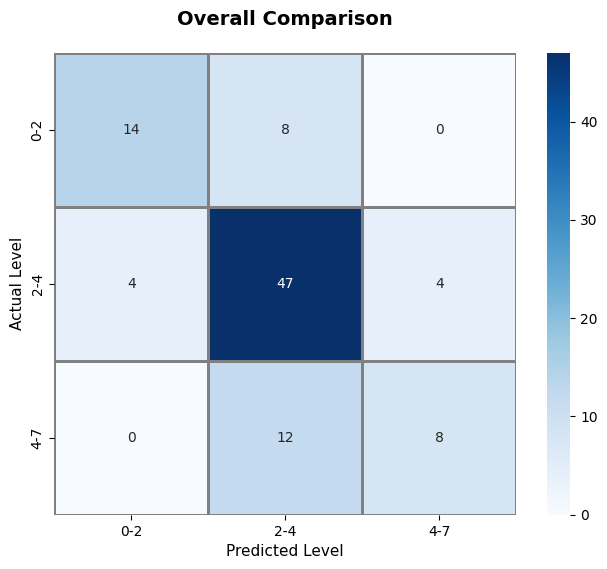


--- REPORT: Overall Comparison ---
              precision    recall  f1-score   support

         0-2       0.78      0.64      0.70        22
         2-4       0.70      0.85      0.77        55
         4-7       0.67      0.40      0.50        20

    accuracy                           0.71        97
   macro avg       0.72      0.63      0.66        97
weighted avg       0.71      0.71      0.70        97



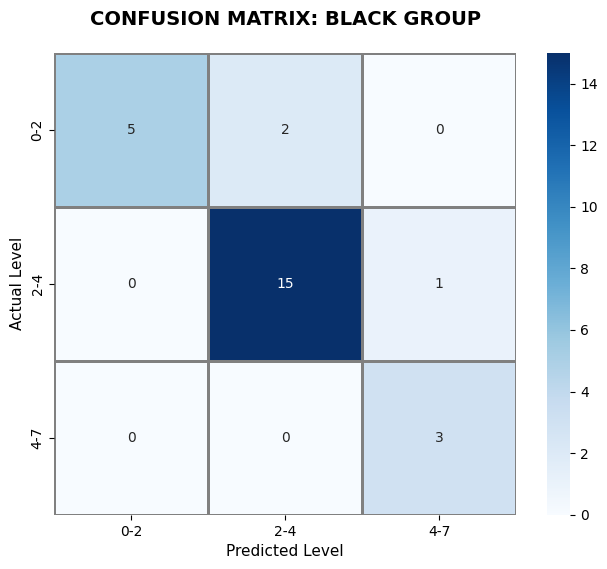


--- REPORT: CONFUSION MATRIX: BLACK GROUP ---
              precision    recall  f1-score   support

         0-2       1.00      0.71      0.83         7
         2-4       0.88      0.94      0.91        16
         4-7       0.75      1.00      0.86         3

    accuracy                           0.88        26
   macro avg       0.88      0.88      0.87        26
weighted avg       0.90      0.88      0.88        26



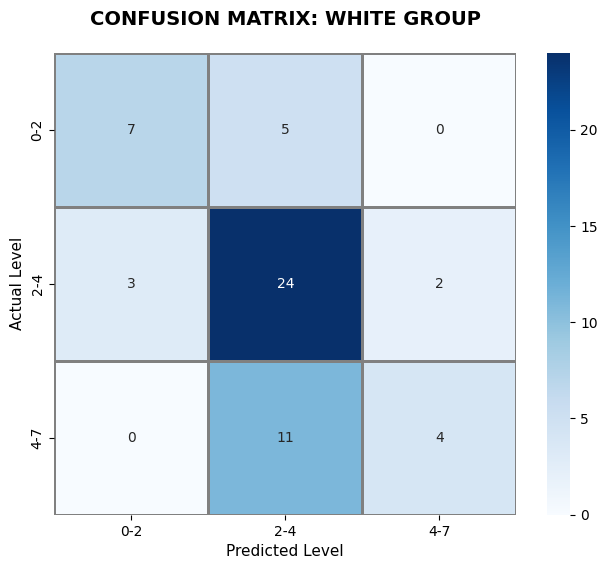


--- REPORT: CONFUSION MATRIX: WHITE GROUP ---
              precision    recall  f1-score   support

         0-2       0.70      0.58      0.64        12
         2-4       0.60      0.83      0.70        29
         4-7       0.67      0.27      0.38        15

    accuracy                           0.62        56
   macro avg       0.66      0.56      0.57        56
weighted avg       0.64      0.62      0.60        56



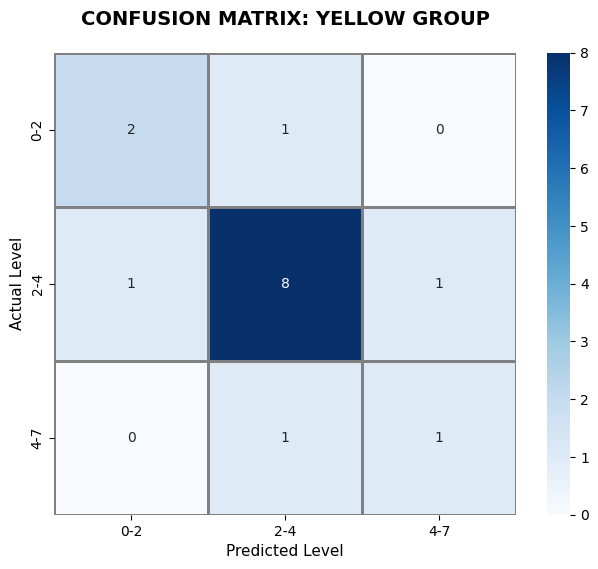


--- REPORT: CONFUSION MATRIX: YELLOW GROUP ---
              precision    recall  f1-score   support

         0-2       0.67      0.67      0.67         3
         2-4       0.80      0.80      0.80        10
         4-7       0.50      0.50      0.50         2

    accuracy                           0.73        15
   macro avg       0.66      0.66      0.66        15
weighted avg       0.73      0.73      0.73        15



C:\Users\USER\AppData\Local\Temp\ipykernel_23196\1779093647.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats = results_df.groupby('Group').apply(lambda x: pd.Series({


,Group,Count,MAE,Bias
0,Black,24.0,0.368142,0.124591
1,White,44.0,0.422838,-0.084399
2,Yellow,29.0,0.619215,-0.371831


In [6]:
import os

if 'results' in locals() and results:
    df_r = pd.DataFrame(results, columns=['Image', 'TrueScore', 'PredScore', 'Error'])
    
    # --- BƯỚC SỬA: Đọc mapping chính xác từ file test_list.txt ---
    # Bạn hãy kiểm tra đường dẫn cfg.TEST_LIST_PATH xem có đúng file test đang dùng không
    mapping_groups = {}
    if os.path.exists(cfg.TEST_LIST_PATH):
        with open(cfg.TEST_LIST_PATH, 'r') as f:
            for line in f:
                parts = line.strip().split('|')
                if len(parts) >= 3:
                    img_name = parts[0].strip()
                    # Lấy phần "Black" từ "Black_Female"
                    actual_group = parts[2].strip().split('_')[0] 
                    mapping_groups[img_name] = actual_group
    
    # Gán nhóm dựa trên mapping thay vì split tên file
    def get_exact_group(img_name):
        return mapping_groups.get(img_name, "Unknown")
    
    df_r['ColorGroup'] = df_r['Image'].apply(get_exact_group)
    
    # Kiểm tra lại số lượng (Lúc này chắc chắn sẽ là Black: 26, White: 56, Yellow: 15)
    print("✅ Thống kê CHÍNH XÁC từ test_list.txt:")
    print(df_r['ColorGroup'].value_counts())
    
    # --- Tiếp tục vẽ như cũ ---
    plot_pain_confusion_matrix(df_r['TrueScore'], df_r['PredScore'], title="Overall Comparison")
    
    for g in ['Black', 'White', 'Yellow']:
        dg = df_r[df_r['ColorGroup'] == g]
        if len(dg) > 0:
            plot_pain_confusion_matrix(dg['TrueScore'], dg['PredScore'], color_group=g)
            
    display(calculate_group_metrics(df_r))
else:
    print("Vui lòng chạy các cell training/test trước.")


## biểu đồ 10 ảnh dự đoán sai tổng quát


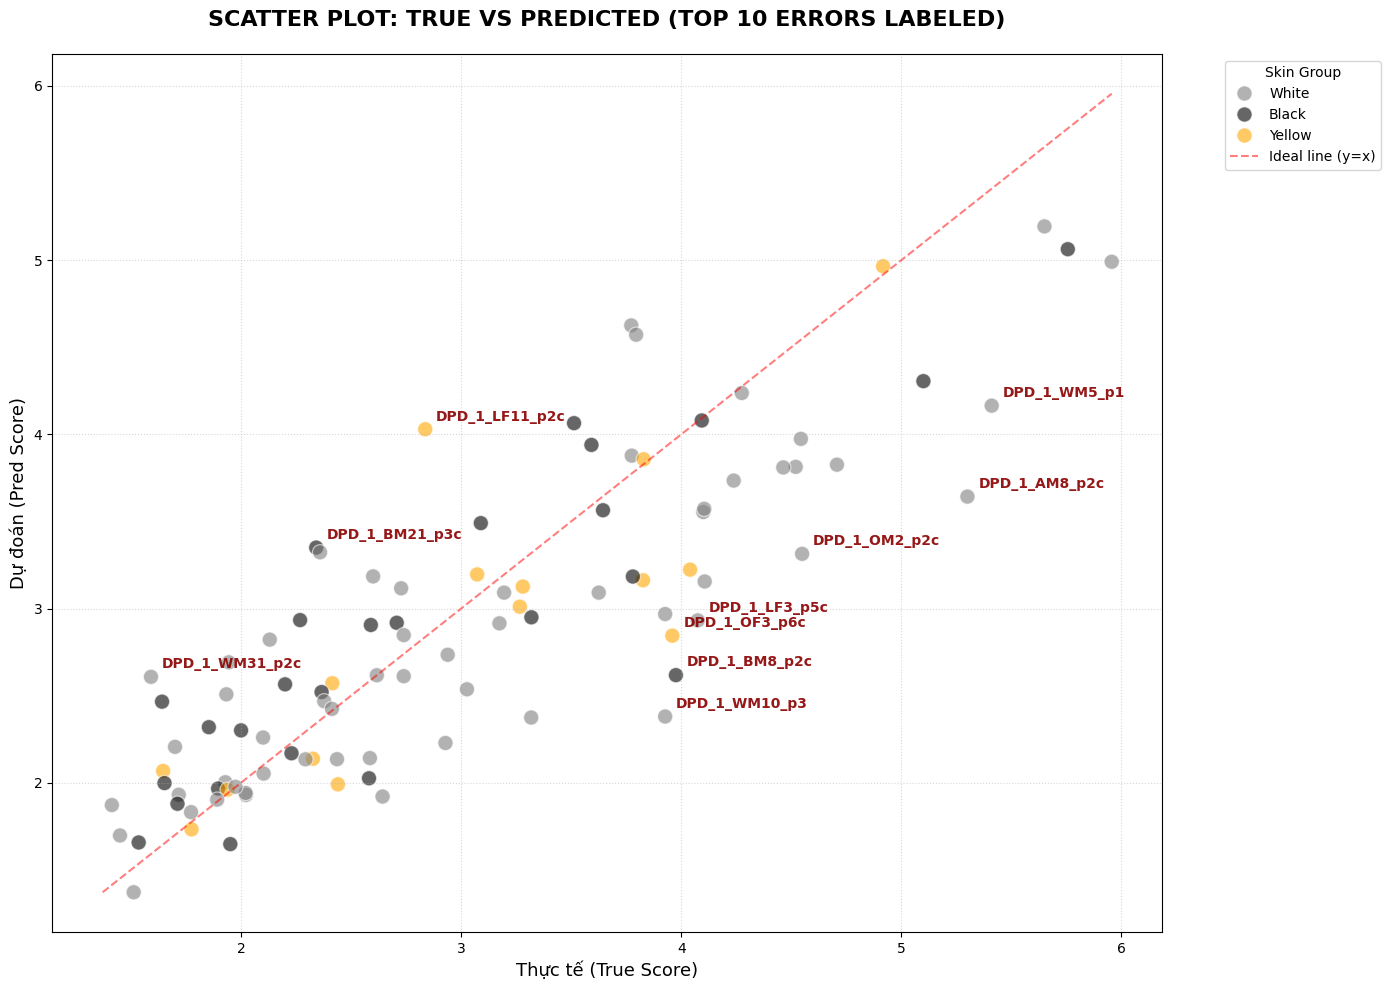

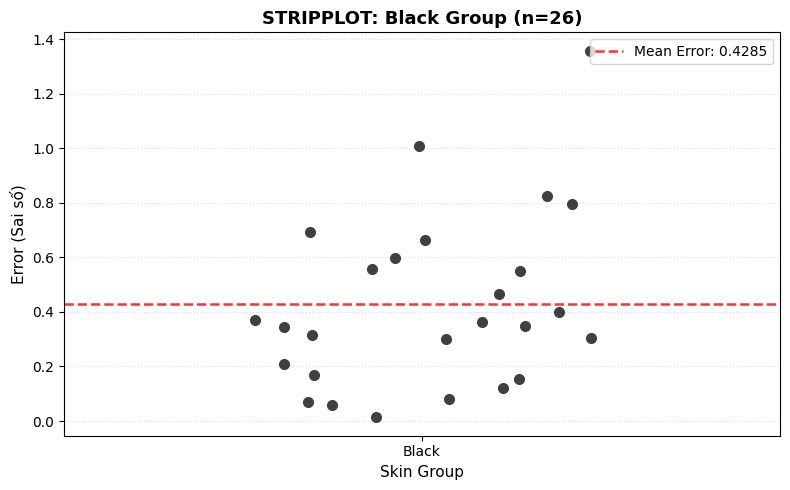

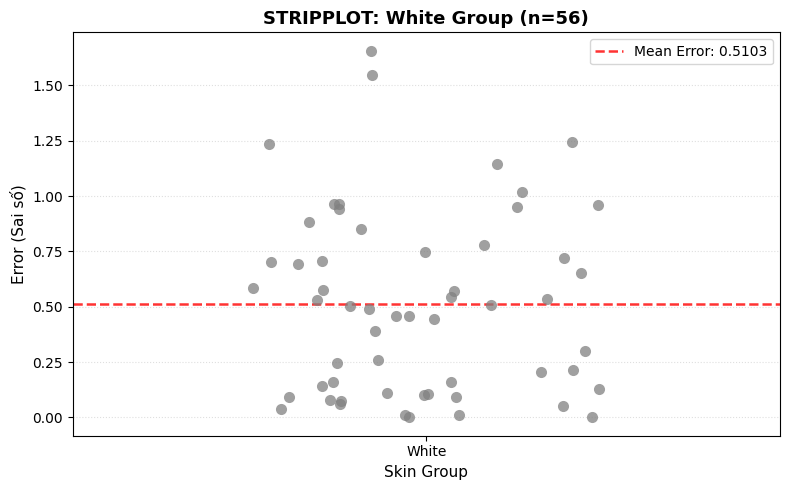

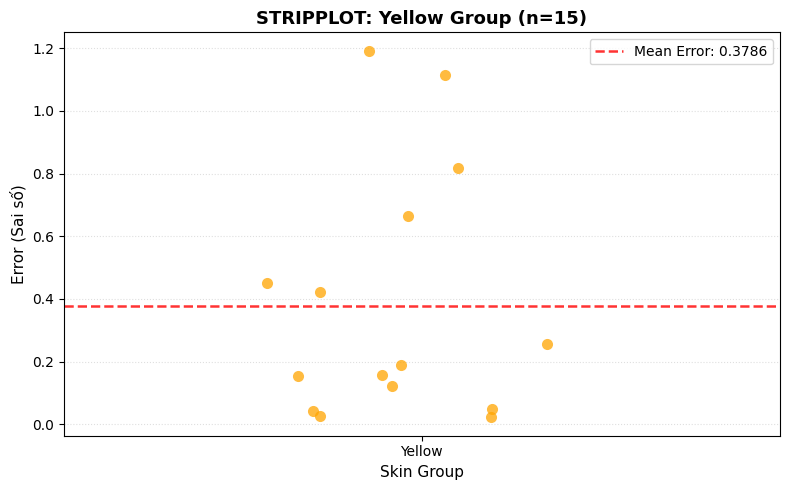


 🔍 DANH SÁCH CHI TIẾT TOP 10 ẢNH CÓ SAI SỐ (ERROR) CAO NHẤT:


,Image,ColorGroup,TrueScore,PredScore,Error
0,DPD_1_AM8_p2c.png,White,5.3000,3.642583,1.657417
1,DPD_1_WM10_p3.png,White,3.9268,2.380060,1.546740
2,DPD_1_BM8_p2c.png,Black,3.9756,2.617527,1.358073
3,DPD_1_WM5_p1.png,White,5.4103,4.164737,1.245563
4,DPD_1_OM2_p2c.png,White,4.5490,3.313959,1.235041
5,DPD_1_LF11_p2c.png,Yellow,2.8367,4.029269,1.192569
6,DPD_1_LF3_p5c.png,White,4.0750,2.931895,1.143105
7,DPD_1_OF3_p6c.png,Yellow,3.9592,2.844186,1.115014
8,DPD_1_WM31_p2c.png,White,1.5909,2.607819,1.016919
9,DPD_1_BM21_p3c.png,Black,2.3415,3.349713,1.008213


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_scatter_with_top_10_labels(df):
    plt.figure(figsize=(14, 10))
    
    # 1. Vẽ các điểm dữ liệu chính
    # palette có thể điều chỉnh tùy ý màu sắc của từng nhóm
    sns.scatterplot(
        data=df, 
        x='TrueScore', y='PredScore', 
        hue='ColorGroup', 
        palette={'Black': 'black', 'White': 'gray', 'Yellow': 'orange'},
        alpha=0.6, 
        s=120,
        edgecolor='w'
    )
    
    # 2. Vẽ đường dự đoán lý tưởng (y=x)
    max_v = max(df['TrueScore'].max(), df['PredScore'].max())
    min_v = min(df['TrueScore'].min(), df['PredScore'].min())
    plt.plot([min_v, max_v], [min_v, max_v], color='red', linestyle='--', alpha=0.5, label='Ideal line (y=x)')
    
    # 3. XÁC ĐỊNH TOP 10 ẢNH SAI SỐ LỚN NHẤT ĐỂ HIỆN TÊN
    top_10 = df.nlargest(10, 'Error')
    
    # Ghi tên lên scatter
    for _, row in top_10.iterrows():
        # Xóa bớt .png để tên gọn hơn
        clean_name = row['Image'].replace('.png', '')
        
        plt.text(
            row['TrueScore'] + 0.05, 
            row['PredScore'] + 0.05, 
            clean_name, 
            fontsize=10, 
            fontweight='bold',
            color='darkred', # Màu đỏ đậm nổi bật
            alpha=0.9
        )
    
    # 4. Trang trí biểu đồ
    plt.title("SCATTER PLOT: TRUE VS PREDICTED (TOP 10 ERRORS LABELED)", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Thực tế (True Score)', fontsize=13)
    plt.ylabel('Dự đoán (Pred Score)', fontsize=13)
    plt.legend(title='Skin Group', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_stripplots_by_color(df):
    """Vẽ 3 stripplot riêng cho từng nhóm màu da, mỗi nhóm một hình to"""
    color_groups = ['Black', 'White', 'Yellow']
    colors_palette = {'Black': 'black', 'White': 'gray', 'Yellow': 'orange'}

    for color_group in color_groups:
        df_filtered = df[df['ColorGroup'] == color_group]
        if df_filtered.empty:
            continue

        plt.figure(figsize=(8, 5))
        sns.stripplot(
            data=df_filtered,
            x='ColorGroup',
            y='Error',
            color=colors_palette[color_group],
            size=8,
            alpha=0.75,
            jitter=0.25
        )

        mean_error = df_filtered['Error'].mean()
        plt.axhline(
            y=mean_error,
            color='red',
            linestyle='--',
            linewidth=1.8,
            alpha=0.8,
            label=f'Mean Error: {mean_error:.4f}'
        )

        plt.title(f"STRIPPLOT: {color_group} Group (n={len(df_filtered)})", fontsize=13, fontweight='bold')
        plt.xlabel('Skin Group', fontsize=11)
        plt.ylabel('Error (Sai số)', fontsize=11)
        plt.grid(True, linestyle=':', alpha=0.4, axis='y')
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()


# THỰC THI (Hiển thị đồng thời cả Đồ thị và Bảng)
if 'df_r' in locals() and not df_r.empty:
    # Vẽ Biểu đồ scatter chính
    plot_scatter_with_top_10_labels(df_r)
    
    # Vẽ 3 stripplot cho từng nhóm màu da
    plot_stripplots_by_color(df_r)
    
    # Hiển thị List bên dưới
    print("\n" + "="*80)
    print(" 🔍 DANH SÁCH CHI TIẾT TOP 10 ẢNH CÓ SAI SỐ (ERROR) CAO NHẤT:")
    print("="*80)
    # Lọc lấy 10 ảnh sai số lớn nhất để hiển thị bảng
    display(df_r.nlargest(10, 'Error')[['Image', 'ColorGroup', 'TrueScore', 'PredScore', 'Error']])
else:
    print("⚠️ Dữ liệu 'df_r' chưa sẵn sàng. Vui lòng chạy cell phân tích Group ở trên trước nhé.")

## Biểu đồ phân bổ sai số (Error Distribution - Boxplots & Violin Plots)


C:\Users\USER\AppData\Local\Temp\ipykernel_21720\3227703078.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ColorGroup', y='Error', palette='Set2', width=0.5)
C:\Users\USER\AppData\Local\Temp\ipykernel_21720\3227703078.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='ColorGroup', y='IndividualBias', inner="quartile", palette='Pastel1')


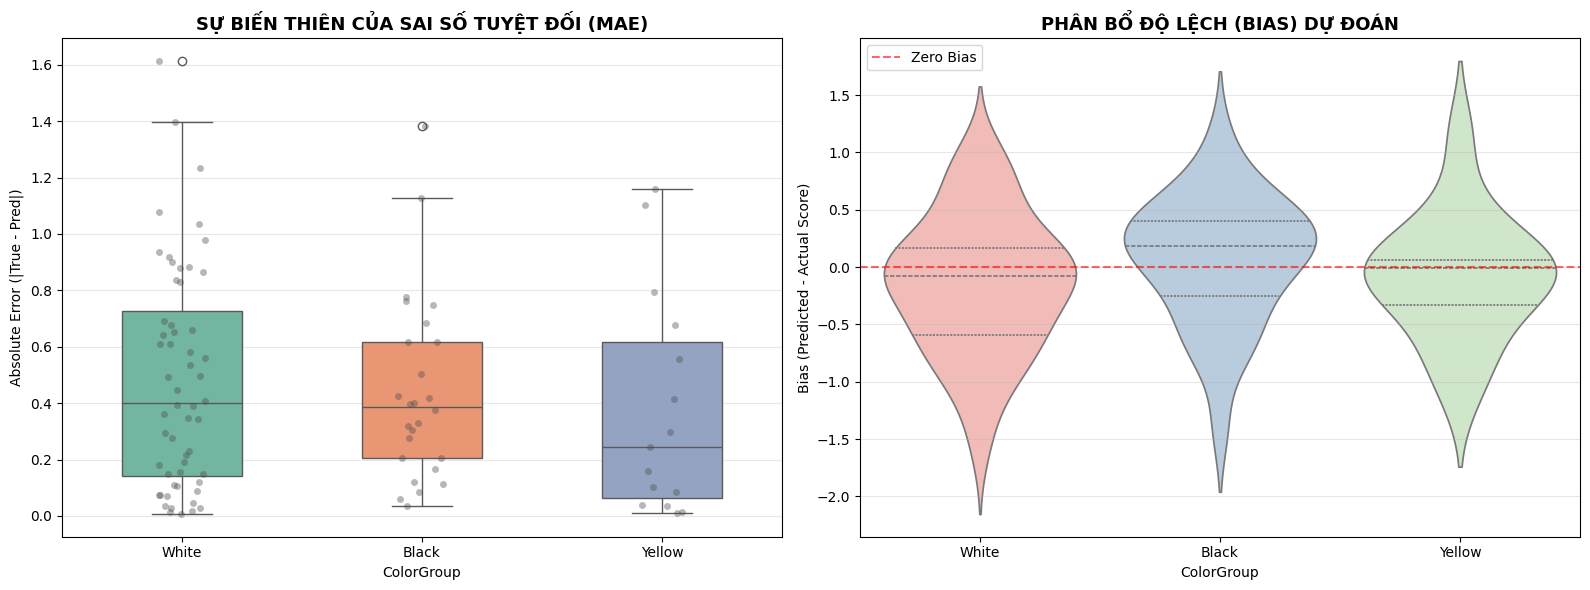


 🔬 KIỂM TRA TÍNH CÓ Ý NGHĨA THỐNG KÊ (P-VALUE) GIỮA CÁC NHÓM:
- So sánh Black vs White: p-value = 0.6300 -> 🟢 KHÔNG CÓ KHÁC BIỆT Ý NGHĨA
- So sánh Black vs Yellow: p-value = 0.6142 -> 🟢 KHÔNG CÓ KHÁC BIỆT Ý NGHĨA
- So sánh White vs Yellow: p-value = 0.3828 -> 🟢 KHÔNG CÓ KHÁC BIỆT Ý NGHĨA
Gợi ý báo cáo: Nếu p-value > 0.05, bạn có thể kết luận model CHƯA cho thấy bằng chứng bias mạnh về mặt thống kê giữa 2 nhóm này.


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def analyze_fairness_deeply(df):
    plt.figure(figsize=(16, 6))
    
    # --- 1. BIỂU ĐỒ BOXPLOT SOI LỖI (MAE) ---
    plt.subplot(1, 2, 1)
    sns.boxplot(data=df, x='ColorGroup', y='Error', palette='Set2', width=0.5)
    sns.stripplot(data=df, x='ColorGroup', y='Error', color=".3", alpha=0.4) # Vẽ thêm các điểm li ti
    plt.title("SỰ BIẾN THIÊN CỦA SAI SỐ TUYỆT ĐỐI (MAE)", fontsize=13, fontweight='bold')
    plt.ylabel("Absolute Error (|True - Pred|)")
    plt.grid(True, axis='y', alpha=0.3)
    
    # --- 2. BIỂU ĐỒ VIOLIN SOI ĐỘ LỆCH (BIAS) ---
    plt.subplot(1, 2, 2)
    # Tính Bias từng ảnh: Dương = Model đoán cao hơn thực tế, Âm = Model đoán thấp hơn thực tế
    df['IndividualBias'] = df['PredScore'] - df['TrueScore']
    sns.violinplot(data=df, x='ColorGroup', y='IndividualBias', inner="quartile", palette='Pastel1')
    plt.axhline(0, color='red', linestyle='--', alpha=0.6, label='Zero Bias')
    plt.title("PHÂN BỔ ĐỘ LỆCH (BIAS) DỰ ĐOÁN", fontsize=13, fontweight='bold')
    plt.ylabel("Bias (Predicted - Actual Score)")
    plt.legend()
    plt.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # --- 3. KIỀM ĐỊNH THỐNG KÊ (P-VALUE) ---
    print("\n" + "="*80)
    print(" 🔬 KIỂM TRA TÍNH CÓ Ý NGHĨA THỐNG KÊ (P-VALUE) GIỮA CÁC NHÓM:")
    print("="*80)
    
    groups = ['Black', 'White', 'Yellow']
    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            g1_err = df[df['ColorGroup'] == groups[i]]['Error']
            g2_err = df[df['ColorGroup'] == groups[j]]['Error']
            
            # Sử dụng Independent T-test
            t_stat, p_val = stats.ttest_ind(g1_err, g2_err, equal_var=False)
            
            status = "🔴 CÓ KHÁC BIỆT Ý NGHĨA" if p_val < 0.05 else "🟢 KHÔNG CÓ KHÁC BIỆT Ý NGHĨA"
            print(f"- So sánh {groups[i]} vs {groups[j]}: p-value = {p_val:.4f} -> {status}")
    print("="*80)
    print("Gợi ý báo cáo: Nếu p-value > 0.05, bạn có thể kết luận model CHƯA cho thấy bằng chứng bias mạnh về mặt thống kê giữa 2 nhóm này.")

if 'df_r' in locals() and not df_r.empty:
    analyze_fairness_deeply(df_r)
